<a href="https://colab.research.google.com/github/AliyuLegend/ALegend/blob/main/Election.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### SENTIMENT ANALYSIS FOR NIGERIAN ELECTION PREDICTION (*A Machine Learning Approach to Predict Election Outcomes from News Articles*) ###



## 1. IMPORTING MAIN LIBRARIES


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Main libraries imported successfully")


✓ Main libraries imported successfully


## 2. NLTK DOWNLOADS

In [9]:
import nltk

# Download required NLTK data
print("Downloading NLTK resources...")
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt_tab') # Added to resolve LookupError

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

print("✓ NLTK resources downloaded successfully")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


✓ NLTK resources downloaded successfully


## 3. INSTALLING/IMPORTING NECESSARY LIBRARIES

In [12]:
# Install additional libraries (for Colab)
print("Installing additional libraries...")
try:
    import textblob
except ImportError:
    !pip install textblob
finally:
    from textblob import TextBlob

try:
    import wordcloud
except ImportError:
    !pip install wordcloud
finally:
    from wordcloud import WordCloud

print("✓ All libraries installed and imported successfully")

Installing additional libraries...
✓ All libraries installed and imported successfully


## 4. IMPORTING DATASETS

In [6]:
print("\n" + "="*70)
print("LOADING DATASET")
print("="*70)

# Upload file in Colab
from google.colab import files
print("Please upload your CSV file:")
uploaded = files.upload()

# Get the filename
filename = list(uploaded.keys())[0]
print(f"\nFile uploaded: {filename}")

# Load the dataset
df = pd.read_csv(filename)

print(f"✓ Dataset loaded successfully!")
print(f"Total records: {len(df)}")
print(f"\nDataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Display first few rows
print("\nFirst 5 rows of the dataset:")
df.head()


LOADING DATASET
Please upload your CSV file:


Saving gdelt_many_tidy2.csv to gdelt_many_tidy2 (1).csv

File uploaded: gdelt_many_tidy2 (1).csv
✓ Dataset loaded successfully!
Total records: 15000

Dataset shape: (15000, 7)
Columns: ['article_id', 'text', 'published', 'domain', 'language', 'candidate', 'source']

First 5 rows of the dataset:


,article_id,text,published,domain,language,candidate,source
0,6d2fc24a58bfc590fa51889f1d09c19f,Damagum to Kwankwaso : We hope youll return to...,2025-01-01 00:45:00+00:00,thecable.ng,English,"APC_TINUBU,PDP_ATIKU,KWANKWASO",GDELT
1,01a1c85d39a37a304bff6e90e8f10f0e,Damagum to Kwankwaso : Return to PDP and work ...,2025-01-01 18:15:00+00:00,nigerianeye.com,English,"APC_TINUBU,PDP_ATIKU,KWANKWASO",GDELT
2,ebe272f1621c46a35669a55612d1995a,"2027 : Return To PDP , Let Confront Tinubu Op...",2025-01-01 10:45:00+00:00,informationng.com,English,"APC_TINUBU,PDP_ATIKU,KWANKWASO",GDELT
3,acd766ecb06e8727d9f8a6670ec0906d,"New Year : Address Insecurity , Fuel , Food Cr...",2025-01-01 10:30:00+00:00,dailytrust.com,English,"APC_TINUBU,PDP_ATIKU",GDELT
4,c0670547784a53140c9d07e775c72864,Tinubu New Year speech shows he lost touch wit...,2025-01-01 23:30:00+00:00,theeagleonline.com.ng,English,"APC_TINUBU,PDP_ATIKU",GDELT


## 5. DATA ASSESSMENT


DATA ASSESSMENT

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   article_id  15000 non-null  object
 1   text        15000 non-null  object
 2   published   15000 non-null  object
 3   domain      15000 non-null  object
 4   language    15000 non-null  object
 5   candidate   15000 non-null  object
 6   source      15000 non-null  object
dtypes: object(7)
memory usage: 820.4+ KB
None

--- Statistical Summary ---
                              article_id  \
count                              15000   
unique                               250   
top     6d2fc24a58bfc590fa51889f1d09c19f   
freq                                  60   

                                                     text  \
count                                               15000   
unique                                                248   
top   

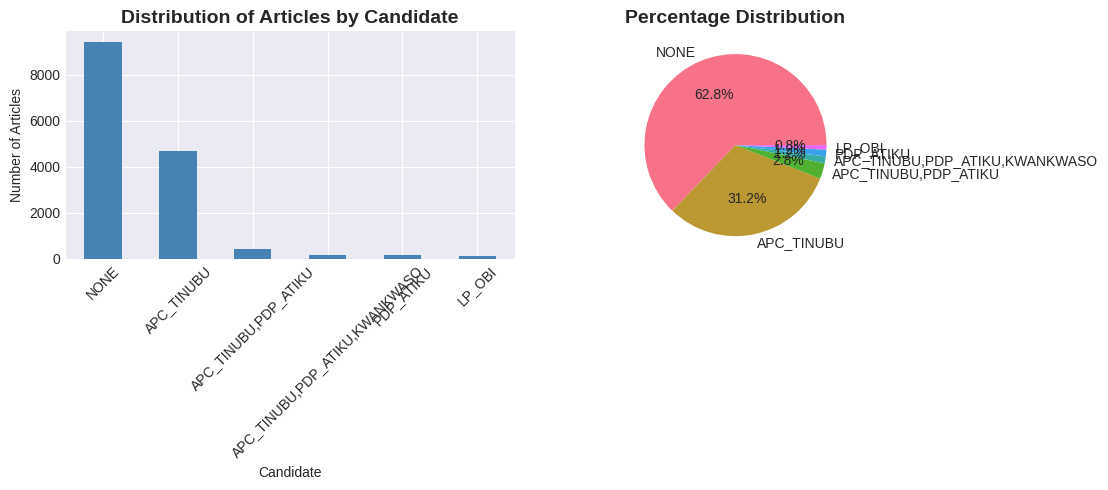


--- Top 10 News Sources ---
domain
tribuneonlineng.com    1200
dailypost.ng           1020
leadership.ng           960
thecable.ng             780
blueprint.ng            780
punchng.com             720
thisdaylive.com         660
nigerianeye.com         540
premiumtimesng.com      540
pmnewsnigeria.com       540
Name: count, dtype: int64


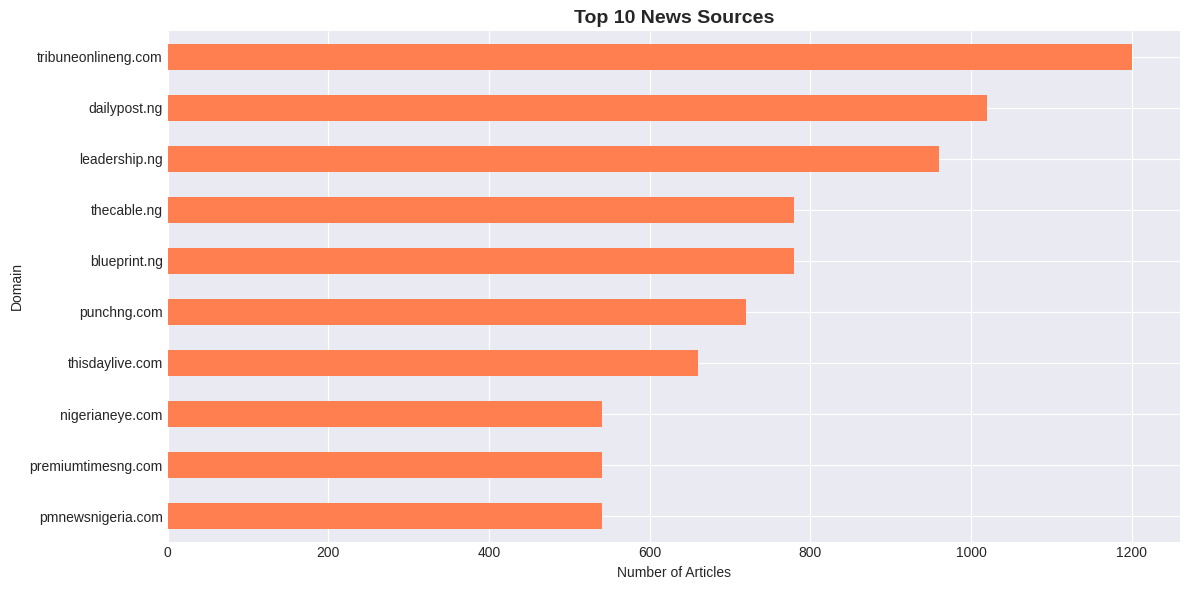


--- Temporal Analysis ---
Date range: 2025-01-01 00:15:00+00:00 to 2025-01-02 00:00:00+00:00


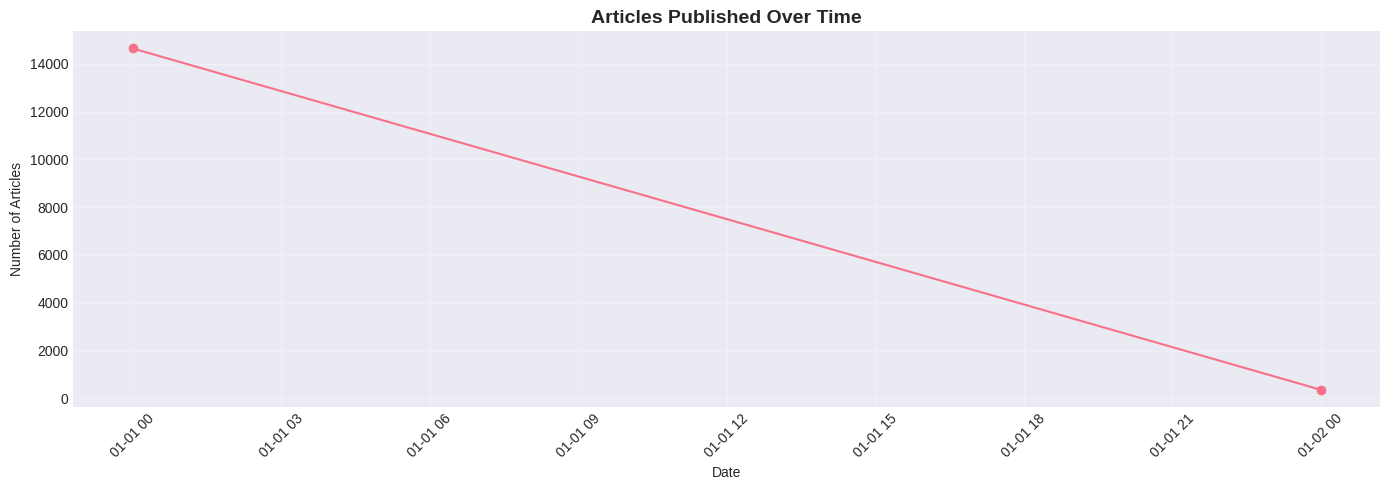


✓ Data assessment completed


In [7]:
print("\n" + "="*70)
print("DATA ASSESSMENT")
print("="*70)

# 5.1 Dataset Information
print("\n--- Dataset Information ---")
print(df.info())

# 5.2 Statistical Summary
print("\n--- Statistical Summary ---")
print(df.describe(include='all'))

# 5.3 Check for Missing Values
print("\n--- Missing Values ---")
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Count': missing_values.values,
    'Percentage': missing_percentage.values
})
print(missing_df[missing_df['Missing Count'] > 0])

# 5.4 Check for Duplicates
print("\n--- Duplicate Records ---")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# 5.5 Data Types
print("\n--- Data Types ---")
print(df.dtypes)

# 5.6 Unique Values per Column
print("\n--- Unique Values ---")
for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")

# 5.7 Candidate Distribution
if 'candidate' in df.columns:
    print("\n--- Candidate Mention Distribution ---")
    print(df['candidate'].value_counts())

    # Visualize candidate distribution
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    df['candidate'].value_counts().plot(kind='bar', color='steelblue')
    plt.title('Distribution of Articles by Candidate', fontsize=14, fontweight='bold')
    plt.xlabel('Candidate')
    plt.ylabel('Number of Articles')
    plt.xticks(rotation=45)

    plt.subplot(1, 2, 2)
    df['candidate'].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.title('Percentage Distribution', fontsize=14, fontweight='bold')
    plt.ylabel('')

    plt.tight_layout()
    plt.show()

# 5.8 Domain/Source Distribution
if 'domain' in df.columns:
    print("\n--- Top 10 News Sources ---")
    top_domains = df['domain'].value_counts().head(10)
    print(top_domains)

    # Visualize top sources
    plt.figure(figsize=(12, 6))
    top_domains.plot(kind='barh', color='coral')
    plt.title('Top 10 News Sources', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Articles')
    plt.ylabel('Domain')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# 5.9 Temporal Distribution
if 'published' in df.columns:
    print("\n--- Temporal Analysis ---")
    df['date'] = pd.to_datetime(df['published'], errors='coerce')
    df['date_only'] = df['date'].dt.date

    print(f"Date range: {df['date'].min()} to {df['date'].max()}")

    # Articles over time
    plt.figure(figsize=(14, 5))
    df['date_only'].value_counts().sort_index().plot(kind='line', marker='o')
    plt.title('Articles Published Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Number of Articles')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\n✓ Data assessment completed")

## 6. DATA PREPROCESSING

In [10]:
print("\n" + "="*70)
print("DATA PREPROCESSING")
print("="*70)

# 6.1 Data Cleaning
print("\n--- 6.1 Data Cleaning ---")

# Create a copy for processing
df_clean = df.copy()

# Remove duplicates
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Removed {initial_rows - len(df_clean)} duplicate rows")

# Handle missing values in text column
if 'text' in df_clean.columns:
    df_clean['text'] = df_clean['text'].fillna('')
    print(f"Filled {df['text'].isnull().sum()} missing text values")

# Handle missing values in candidate column
if 'candidate' in df_clean.columns:
    df_clean['candidate'] = df_clean['candidate'].fillna('UNKNOWN')

# Remove rows with empty text
df_clean = df_clean[df_clean['text'].str.strip() != '']
print(f"Dataset after cleaning: {len(df_clean)} rows")

# 6.2 Text Preprocessing Function
print("\n--- 6.2 Text Preprocessing ---")

# Define stopwords
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """
    Comprehensive text preprocessing
    """
    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens
              if word not in stop_words and len(word) > 2]

    return ' '.join(tokens)

# Apply preprocessing
print("Preprocessing text data (this may take a while)...")
df_clean['text_processed'] = df_clean['text'].apply(preprocess_text)
df_clean['text_length'] = df_clean['text'].apply(lambda x: len(str(x)))
df_clean['word_count'] = df_clean['text'].apply(lambda x: len(str(x).split()))

print("✓ Text preprocessing completed")

# Display sample of processed text
print("\n--- Sample Processed Text ---")
sample_idx = df_clean.index[0]
print(f"Original: {df_clean.loc[sample_idx, 'text'][:200]}...")
print(f"\nProcessed: {df_clean.loc[sample_idx, 'text_processed'][:200]}...")

# 6.3 Data Integration and Transformation
print("\n--- 6.3 Data Integration and Transformation ---")

# Extract candidate mentions from text
def extract_candidates(text, candidate_field):
    """Extract candidate mentions from text"""
    candidates_found = []
    text_lower = str(text).lower() + " " + str(candidate_field).lower()

    candidate_patterns = {
        'TINUBU': ['tinubu', 'bola tinubu', 'bola ahmed tinubu', 'bat', 'apc tinubu'],
        'ATIKU': ['atiku', 'atiku abubakar', 'abubakar', 'pdp atiku'],
        'PETER_OBI': ['peter obi', 'peter gregory obi', 'obi', 'lp obi'],
        'KWANKWASO': ['kwankwaso', 'rabiu kwankwaso', 'nnpp kwankwaso']
    }

    for candidate, patterns in candidate_patterns.items():
        for pattern in patterns:
            if pattern in text_lower:
                candidates_found.append(candidate)
                break

    return candidates_found if candidates_found else ['UNKNOWN']

df_clean['extracted_candidates'] = df_clean.apply(
    lambda row: extract_candidates(row['text'], row.get('candidate', '')),
    axis=1
)

# Create binary columns for each candidate
for candidate in ['TINUBU', 'ATIKU', 'PETER_OBI', 'KWANKWASO']:
    df_clean[f'mentions_{candidate}'] = df_clean['extracted_candidates'].apply(
        lambda x: 1 if candidate in x else 0
    )

print("✓ Candidate extraction completed")

# 6.4 Feature Engineering
print("\n--- 6.4 Feature Engineering ---")

# Text statistics
df_clean['avg_word_length'] = df_clean['text'].apply(
    lambda x: np.mean([len(word) for word in str(x).split()]) if len(str(x).split()) > 0 else 0
)

df_clean['sentence_count'] = df_clean['text'].apply(
    lambda x: len(re.split(r'[.!?]+', str(x)))
)

# Categorize article length
df_clean['article_length_category'] = pd.cut(
    df_clean['word_count'],
    bins=[0, 100, 300, 1000, float('inf')],
    labels=['Very Short', 'Short', 'Medium', 'Long']
)

print("✓ Feature engineering completed")
print(f"\nFinal preprocessed dataset: {df_clean.shape}")


DATA PREPROCESSING

--- 6.1 Data Cleaning ---
Removed 14750 duplicate rows
Filled 0 missing text values
Dataset after cleaning: 250 rows

--- 6.2 Text Preprocessing ---
Preprocessing text data (this may take a while)...
✓ Text preprocessing completed

--- Sample Processed Text ---
Original: Damagum to Kwankwaso : We hope youll return to PDP and work with us to challenge Tinubu...

Processed: damagum kwankwaso hope youll return pdp work challenge tinubu...

--- 6.3 Data Integration and Transformation ---
✓ Candidate extraction completed

--- 6.4 Feature Engineering ---
✓ Feature engineering completed

Final preprocessed dataset: (250, 20)


## 7. EXPLORATORY DATA ANALYSIS (EDA)


EXPLORATORY DATA ANALYSIS

--- 7.1 Text Length Distribution ---


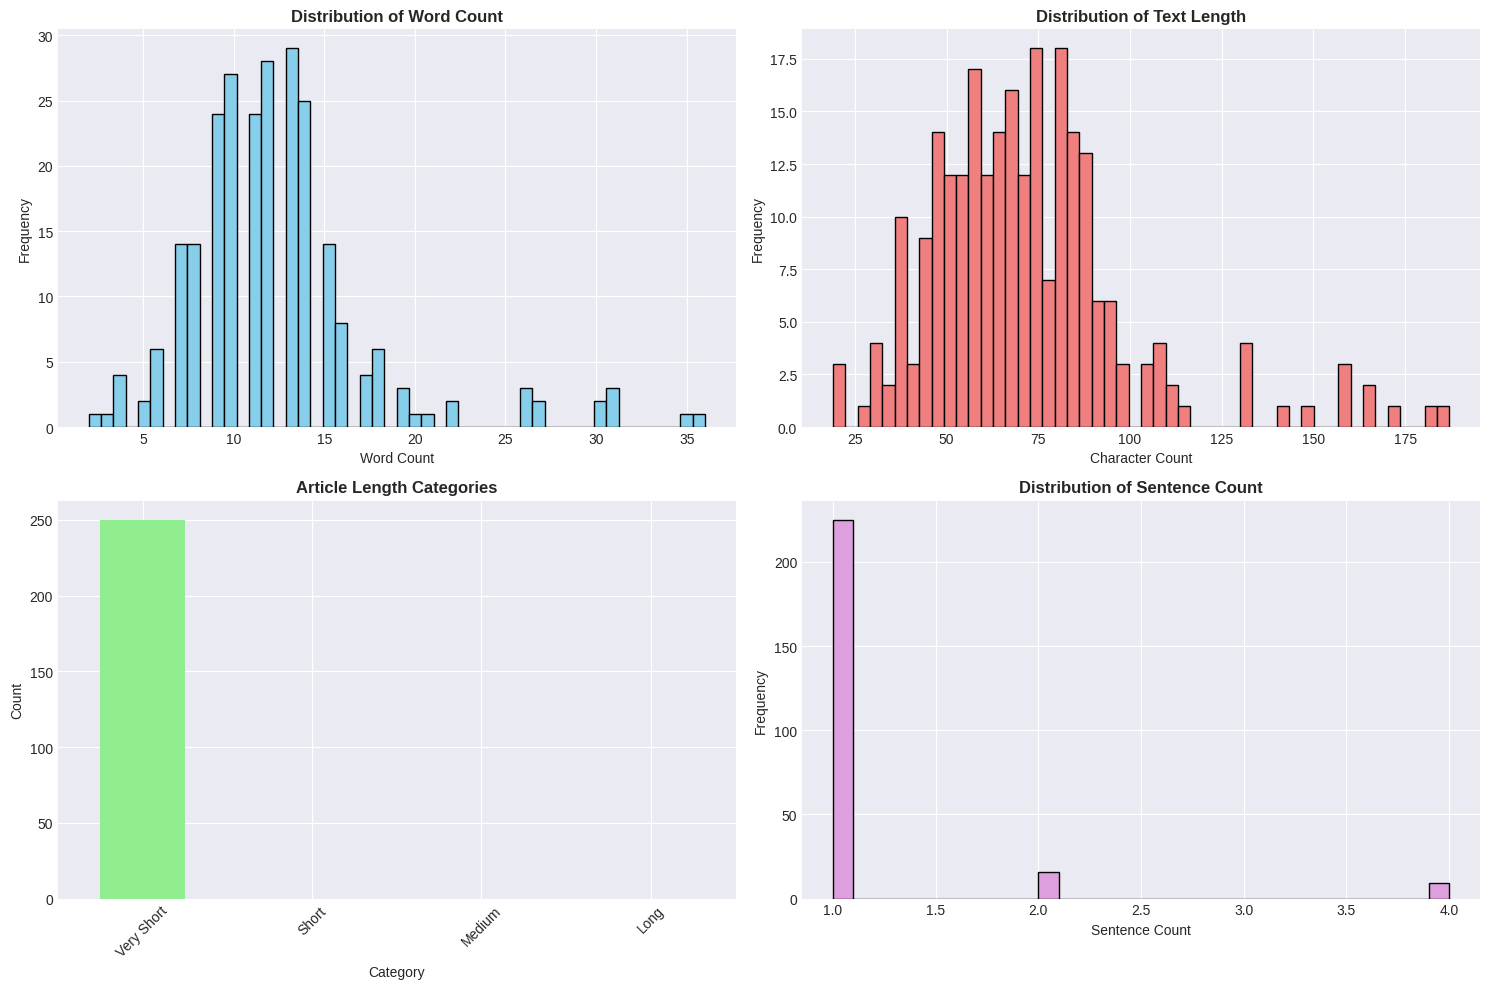

Average word count: 12.41
Average text length: 71.88
Average sentence count: 1.17

--- 7.2 Candidate Mention Analysis ---


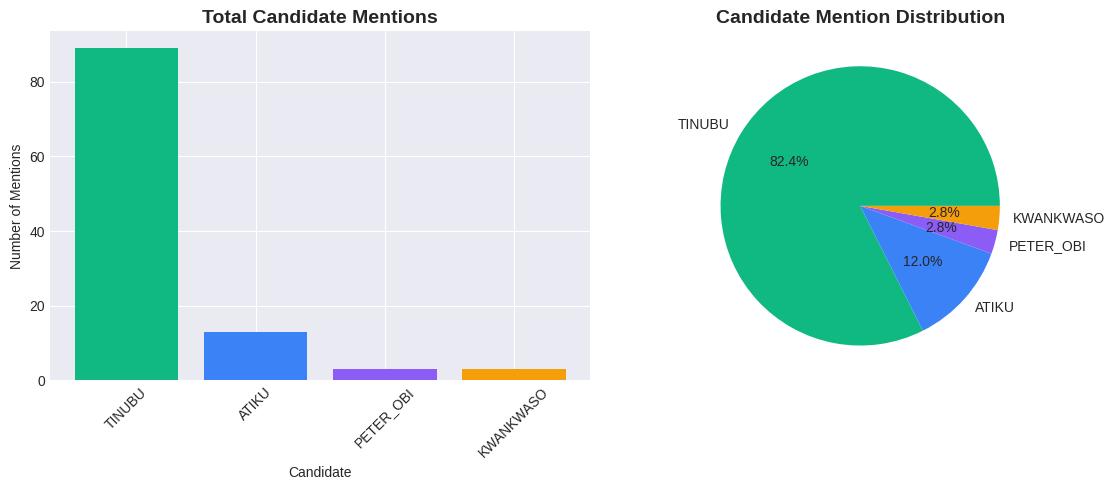

TINUBU: 89 mentions
ATIKU: 13 mentions
PETER_OBI: 3 mentions
KWANKWASO: 3 mentions

--- 7.3 Word Cloud Visualization ---


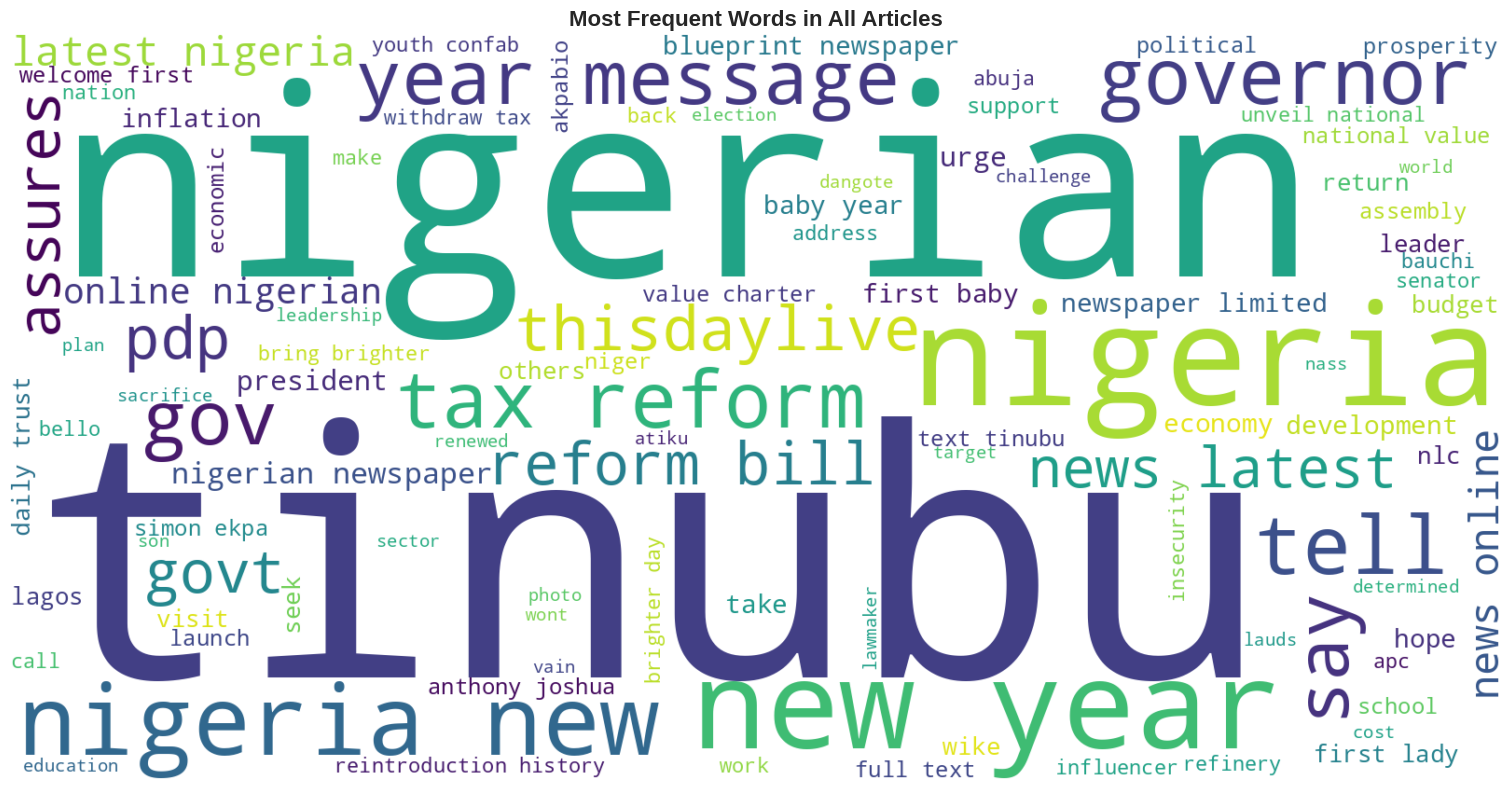

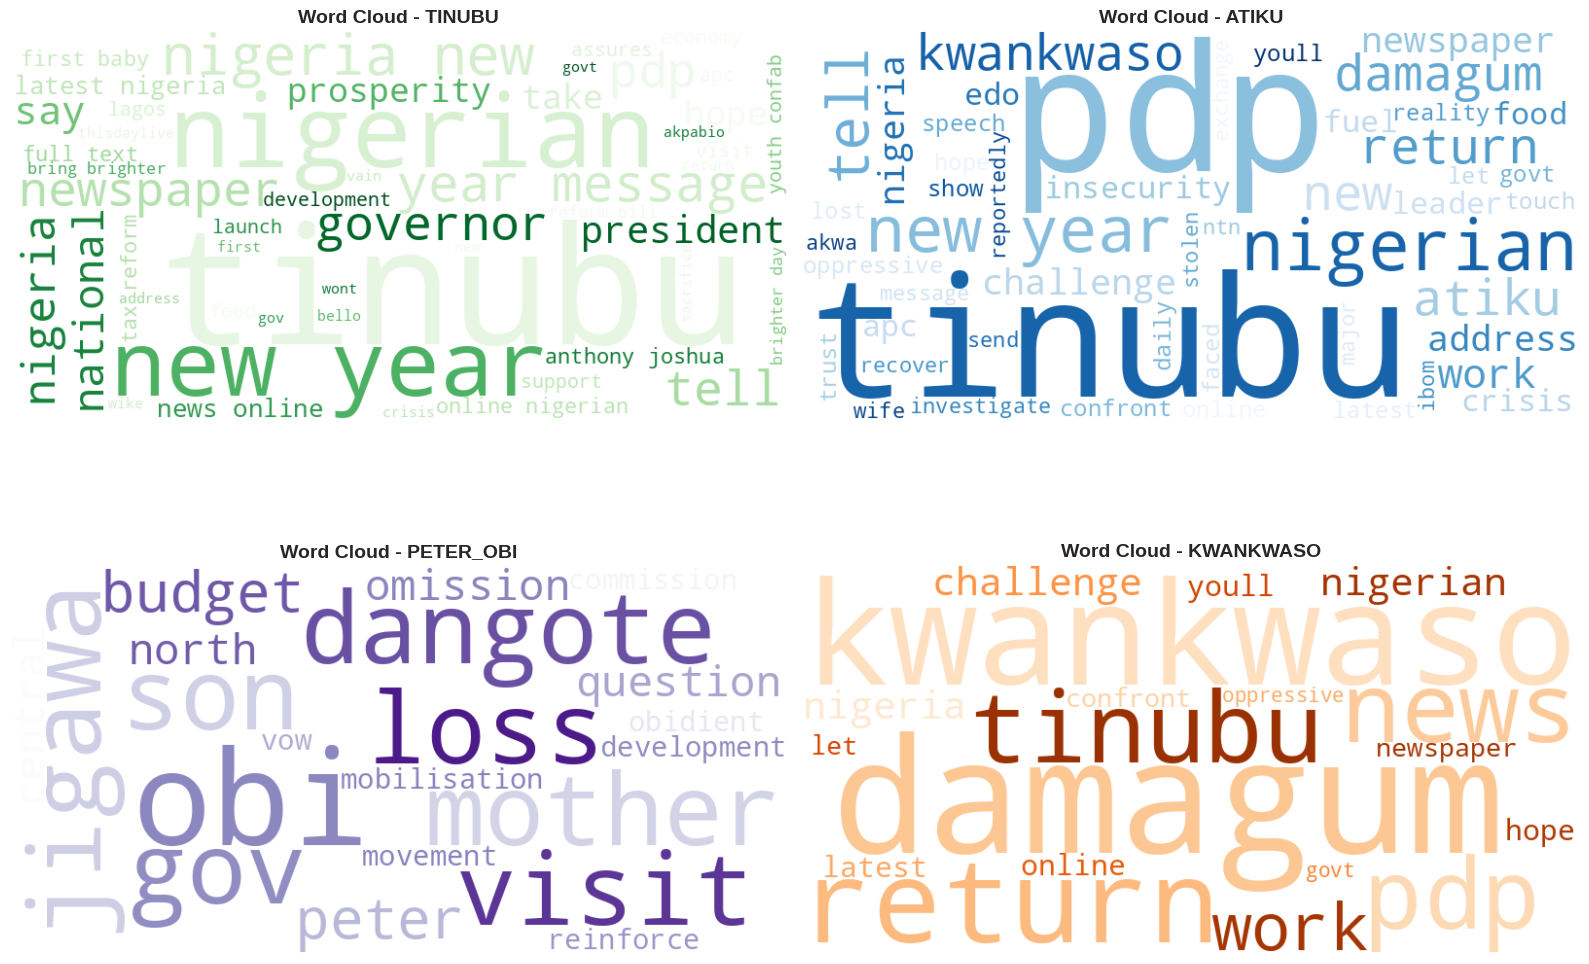


--- 7.4 Top Keywords Analysis ---


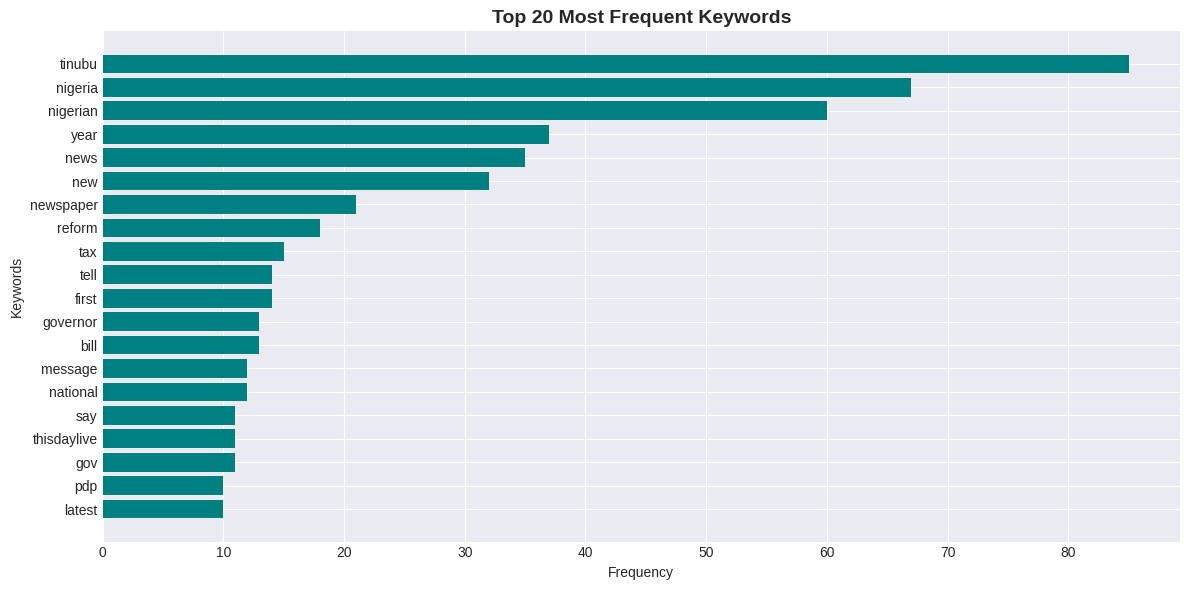


Top 20 Keywords:
  tinubu: 85
  nigeria: 67
  nigerian: 60
  year: 37
  news: 35
  new: 32
  newspaper: 21
  reform: 18
  tax: 15
  tell: 14
  first: 14
  governor: 13
  bill: 13
  message: 12
  national: 12
  say: 11
  thisdaylive: 11
  gov: 11
  pdp: 10
  latest: 10

--- 7.5 Sentiment Analysis ---


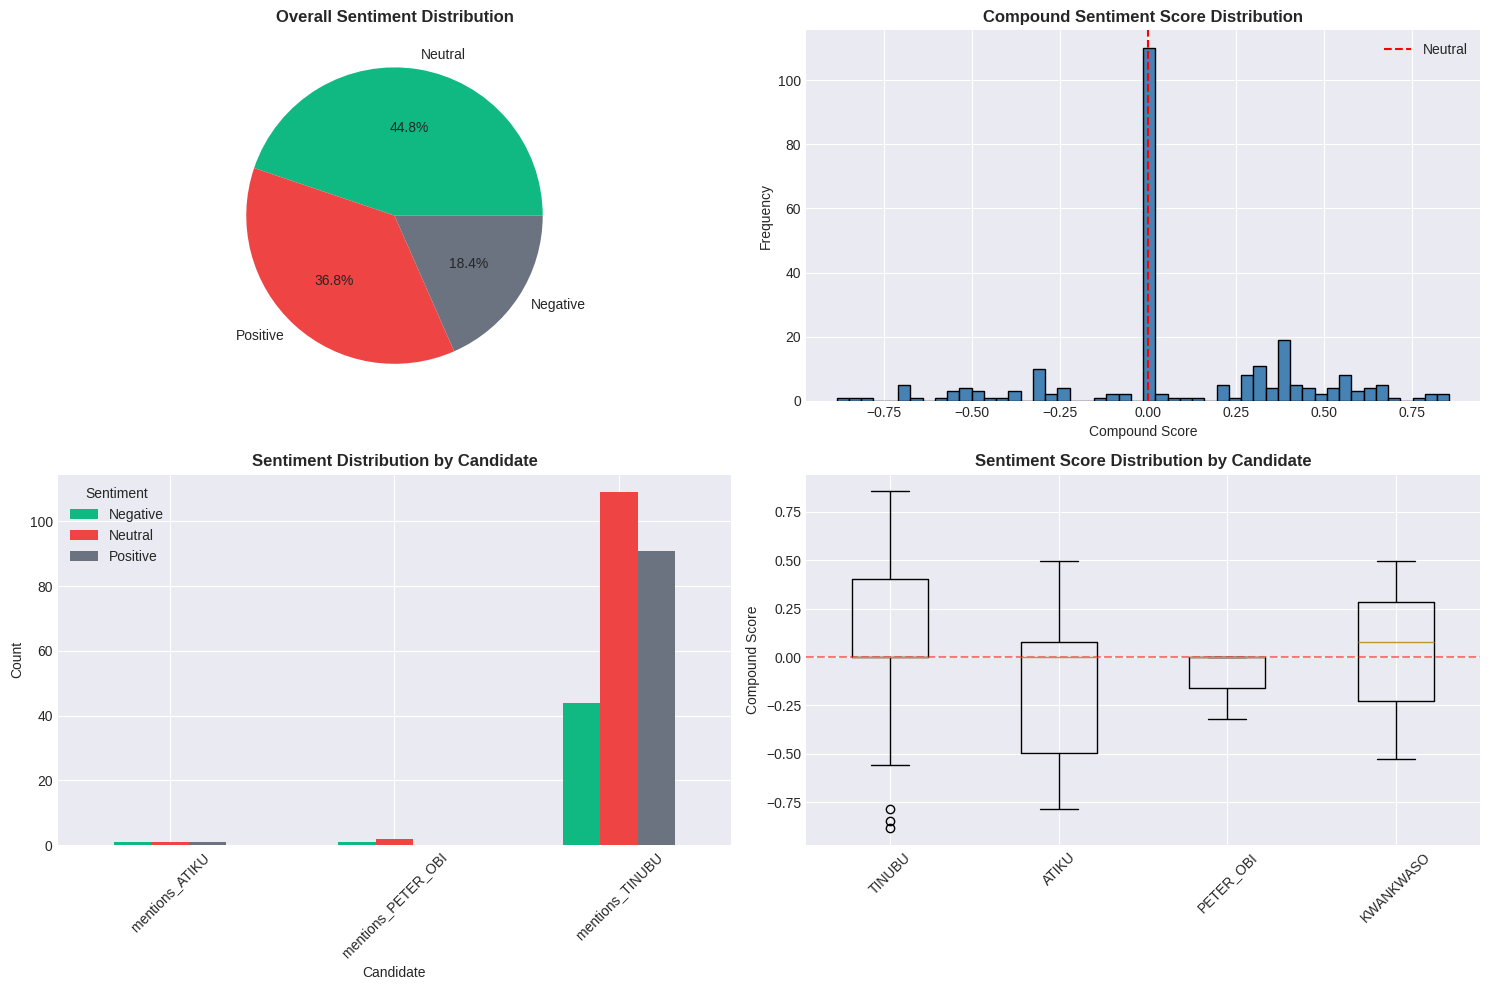


Sentiment Statistics:
sentiment_label
Neutral     112
Positive     92
Negative     46
Name: count, dtype: int64

Average compound score: 0.0824
Median compound score: 0.0000

--- 7.6 Detailed Sentiment Analysis by Candidate ---

TINUBU:
  Articles: 89
  Average Sentiment: 0.1294
  Positive: 41 (46.1%)
  Negative: 14 (15.7%)
  Neutral: 34 (38.2%)

ATIKU:
  Articles: 13
  Average Sentiment: -0.1378
  Positive: 4 (30.8%)
  Negative: 6 (46.2%)
  Neutral: 3 (23.1%)

PETER_OBI:
  Articles: 3
  Average Sentiment: -0.1061
  Positive: 0 (0.0%)
  Negative: 1 (33.3%)
  Neutral: 2 (66.7%)

KWANKWASO:
  Articles: 3
  Average Sentiment: 0.0148
  Positive: 2 (66.7%)
  Negative: 1 (33.3%)
  Neutral: 0 (0.0%)

--- 7.7 Temporal Sentiment Trends ---


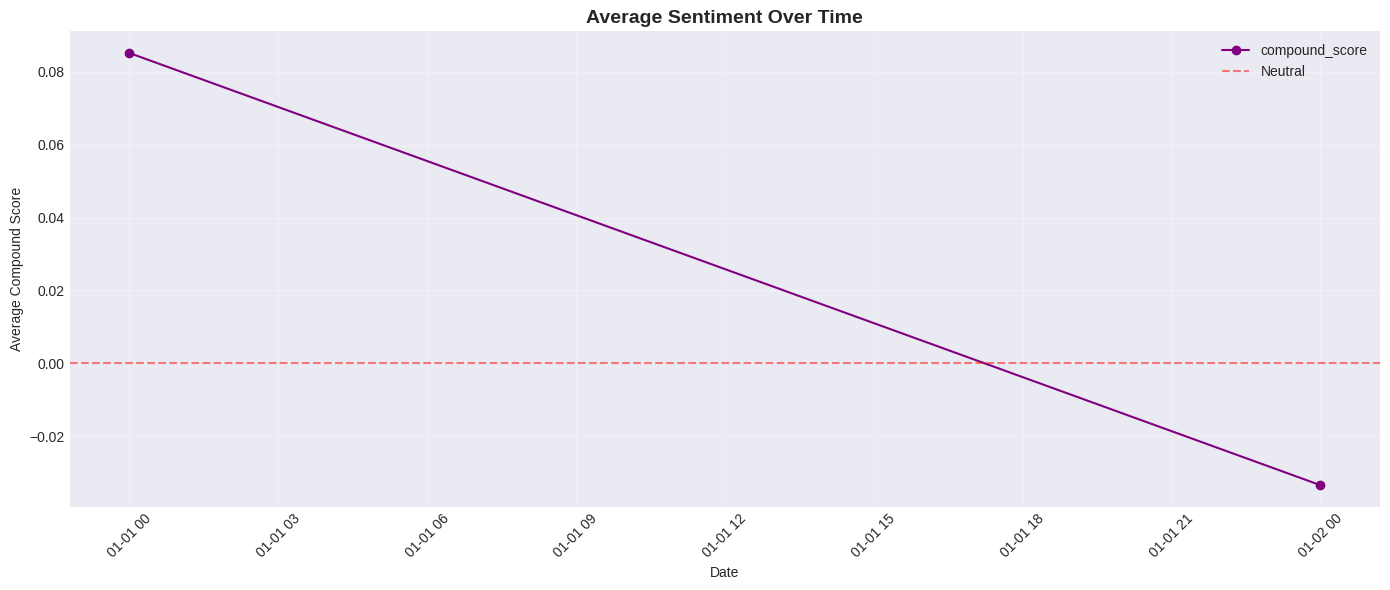


--- 7.8 Correlation Analysis ---


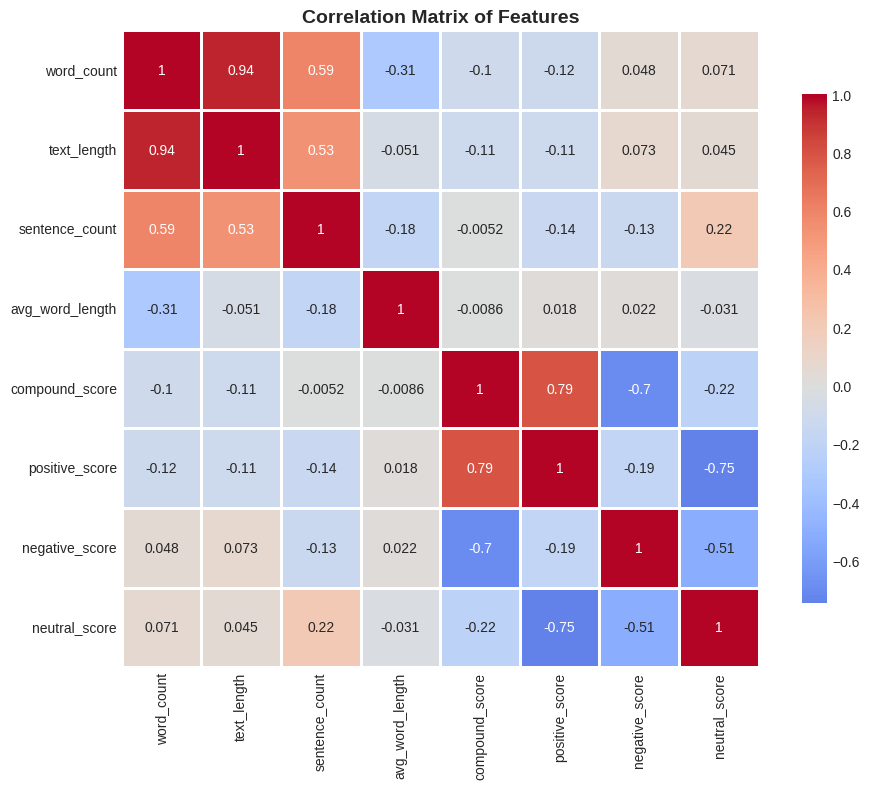


✓ Exploratory Data Analysis completed


In [13]:
print("\n" + "="*70)
print("EXPLORATORY DATA ANALYSIS")
print("="*70)

# 7.1 Text Length Distribution
print("\n--- 7.1 Text Length Distribution ---")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Word count distribution
axes[0, 0].hist(df_clean['word_count'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Word Count', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Word Count')
axes[0, 0].set_ylabel('Frequency')

# Text length distribution
axes[0, 1].hist(df_clean['text_length'], bins=50, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Distribution of Text Length', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Character Count')
axes[0, 1].set_ylabel('Frequency')

# Article length categories
df_clean['article_length_category'].value_counts().plot(kind='bar', ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Article Length Categories', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Category')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# Sentence count distribution
axes[1, 1].hist(df_clean['sentence_count'], bins=30, color='plum', edgecolor='black')
axes[1, 1].set_title('Distribution of Sentence Count', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Sentence Count')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Average word count: {df_clean['word_count'].mean():.2f}")
print(f"Average text length: {df_clean['text_length'].mean():.2f}")
print(f"Average sentence count: {df_clean['sentence_count'].mean():.2f}")

# 7.2 Candidate Mention Analysis
print("\n--- 7.2 Candidate Mention Analysis ---")

candidate_mentions = {
    'TINUBU': df_clean['mentions_TINUBU'].sum(),
    'ATIKU': df_clean['mentions_ATIKU'].sum(),
    'PETER_OBI': df_clean['mentions_PETER_OBI'].sum(),
    'KWANKWASO': df_clean['mentions_KWANKWASO'].sum()
}

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(candidate_mentions.keys(), candidate_mentions.values(),
        color=['#10b981', '#3b82f6', '#8b5cf6', '#f59e0b'])
plt.title('Total Candidate Mentions', fontsize=14, fontweight='bold')
plt.xlabel('Candidate')
plt.ylabel('Number of Mentions')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.pie(candidate_mentions.values(), labels=candidate_mentions.keys(),
        autopct='%1.1f%%', colors=['#10b981', '#3b82f6', '#8b5cf6', '#f59e0b'])
plt.title('Candidate Mention Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

for candidate, count in candidate_mentions.items():
    print(f"{candidate}: {count} mentions")

# 7.3 Word Cloud Analysis
print("\n--- 7.3 Word Cloud Visualization ---")

# Overall word cloud
all_text = ' '.join(df_clean['text_processed'])
wordcloud = WordCloud(width=1600, height=800, background_color='white',
                      colormap='viridis', max_words=100).generate(all_text)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Most Frequent Words in All Articles', fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

# Word clouds for each candidate
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
candidates = ['TINUBU', 'ATIKU', 'PETER_OBI', 'KWANKWASO']
colors = ['Greens', 'Blues', 'Purples', 'Oranges']

for idx, (candidate, color) in enumerate(zip(candidates, colors)):
    row = idx // 2
    col = idx % 2

    # Get articles mentioning this candidate
    candidate_text = ' '.join(
        df_clean[df_clean[f'mentions_{candidate}'] == 1]['text_processed']
    )

    if candidate_text:
        wordcloud = WordCloud(width=800, height=400, background_color='white',
                            colormap=color, max_words=50).generate(candidate_text)
        axes[row, col].imshow(wordcloud, interpolation='bilinear')
        axes[row, col].set_title(f'Word Cloud - {candidate}',
                                fontsize=14, fontweight='bold')
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# 7.4 Top Keywords Analysis
print("\n--- 7.4 Top Keywords Analysis ---")

from collections import Counter

def get_top_keywords(text_series, n=20):
    """Extract top N keywords"""
    all_words = ' '.join(text_series).split()
    word_freq = Counter(all_words)
    return word_freq.most_common(n)

top_keywords = get_top_keywords(df_clean['text_processed'], n=20)

plt.figure(figsize=(12, 6))
words, counts = zip(*top_keywords)
plt.barh(words, counts, color='teal')
plt.title('Top 20 Most Frequent Keywords', fontsize=14, fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Keywords')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 20 Keywords:")
for word, count in top_keywords:
    print(f"  {word}: {count}")

# 7.5 Sentiment Analysis
print("\n--- 7.5 Sentiment Analysis ---")

# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

def get_sentiment_vader(text):
    """Get sentiment using VADER"""
    scores = sia.polarity_scores(str(text))
    return scores

# Apply sentiment analysis
df_clean['sentiment_scores'] = df_clean['text'].apply(get_sentiment_vader)
df_clean['compound_score'] = df_clean['sentiment_scores'].apply(lambda x: x['compound'])
df_clean['positive_score'] = df_clean['sentiment_scores'].apply(lambda x: x['pos'])
df_clean['negative_score'] = df_clean['sentiment_scores'].apply(lambda x: x['neg'])
df_clean['neutral_score'] = df_clean['sentiment_scores'].apply(lambda x: x['neu'])

# Classify sentiment
def classify_sentiment(compound):
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df_clean['sentiment_label'] = df_clean['compound_score'].apply(classify_sentiment)

# Visualize sentiment distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Overall sentiment distribution
sentiment_counts = df_clean['sentiment_label'].value_counts()
axes[0, 0].pie(sentiment_counts.values, labels=sentiment_counts.index,
              autopct='%1.1f%%', colors=['#10b981', '#ef4444', '#6b7280'])
axes[0, 0].set_title('Overall Sentiment Distribution', fontsize=12, fontweight='bold')

# Compound score distribution
axes[0, 1].hist(df_clean['compound_score'], bins=50, color='steelblue', edgecolor='black')
axes[0, 1].set_title('Compound Sentiment Score Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Compound Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(x=0, color='red', linestyle='--', label='Neutral')
axes[0, 1].legend()

# Sentiment by candidate
candidate_sentiment = pd.crosstab(
    df_clean[['mentions_TINUBU', 'mentions_ATIKU', 'mentions_PETER_OBI', 'mentions_KWANKWASO']].idxmax(axis=1),
    df_clean['sentiment_label']
)
candidate_sentiment.plot(kind='bar', ax=axes[1, 0], color=['#10b981', '#ef4444', '#6b7280'])
axes[1, 0].set_title('Sentiment Distribution by Candidate', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Candidate')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(title='Sentiment')

# Box plot of sentiment scores
sentiment_data = [
    df_clean[df_clean['mentions_TINUBU'] == 1]['compound_score'],
    df_clean[df_clean['mentions_ATIKU'] == 1]['compound_score'],
    df_clean[df_clean['mentions_PETER_OBI'] == 1]['compound_score'],
    df_clean[df_clean['mentions_KWANKWASO'] == 1]['compound_score']
]
axes[1, 1].boxplot(sentiment_data, labels=['TINUBU', 'ATIKU', 'PETER_OBI', 'KWANKWASO'])
axes[1, 1].set_title('Sentiment Score Distribution by Candidate', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Compound Score')
axes[1, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nSentiment Statistics:")
print(df_clean['sentiment_label'].value_counts())
print(f"\nAverage compound score: {df_clean['compound_score'].mean():.4f}")
print(f"Median compound score: {df_clean['compound_score'].median():.4f}")

# 7.6 Sentiment by Candidate
print("\n--- 7.6 Detailed Sentiment Analysis by Candidate ---")

for candidate in ['TINUBU', 'ATIKU', 'PETER_OBI', 'KWANKWASO']:
    candidate_df = df_clean[df_clean[f'mentions_{candidate}'] == 1]

    if len(candidate_df) > 0:
        avg_sentiment = candidate_df['compound_score'].mean()
        sentiment_dist = candidate_df['sentiment_label'].value_counts()

        print(f"\n{candidate}:")
        print(f"  Articles: {len(candidate_df)}")
        print(f"  Average Sentiment: {avg_sentiment:.4f}")
        print(f"  Positive: {sentiment_dist.get('Positive', 0)} ({sentiment_dist.get('Positive', 0)/len(candidate_df)*100:.1f}%)")
        print(f"  Negative: {sentiment_dist.get('Negative', 0)} ({sentiment_dist.get('Negative', 0)/len(candidate_df)*100:.1f}%)")
        print(f"  Neutral: {sentiment_dist.get('Neutral', 0)} ({sentiment_dist.get('Neutral', 0)/len(candidate_df)*100:.1f}%)")

# 7.7 Temporal Sentiment Trends
print("\n--- 7.7 Temporal Sentiment Trends ---")

if 'date_only' in df_clean.columns:
    # Group by date and calculate average sentiment
    daily_sentiment = df_clean.groupby('date_only')['compound_score'].mean()

    plt.figure(figsize=(14, 6))
    daily_sentiment.plot(kind='line', marker='o', color='purple')
    plt.title('Average Sentiment Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Average Compound Score')
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Neutral')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 7.8 Correlation Analysis
print("\n--- 7.8 Correlation Analysis ---")

# Select numerical features
numerical_features = ['word_count', 'text_length', 'sentence_count', 'avg_word_length',
                     'compound_score', 'positive_score', 'negative_score', 'neutral_score']

correlation_matrix = df_clean[numerical_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Exploratory Data Analysis completed")

## 8. MACHINE LEARNING MODEL FOR ELECTION PREDICTION


ELECTION OUTCOME PREDICTION MODEL

FINAL ELECTION PREDICTIONS
Candidate  Total Mentions  Avg Sentiment  Positive Coverage (%)  Negative Coverage (%)  Neutral Coverage (%)  Prediction Score  Non_Negative_Prediction_Score  Predicted Vote Share (%)  Rank
   TINUBU              89         0.1294                  46.07                  15.73                 38.20             60.38                          60.38                      70.5     1
KWANKWASO               3         0.0148                  66.67                  33.33                  0.00             25.27                          25.27                      29.5     2
    ATIKU              13        -0.1378                  30.77                  46.15                 23.08             -0.15                           0.00                       0.0     3
PETER OBI               3        -0.1061                   0.00                  33.33                 66.67            -14.10                           0.00                    

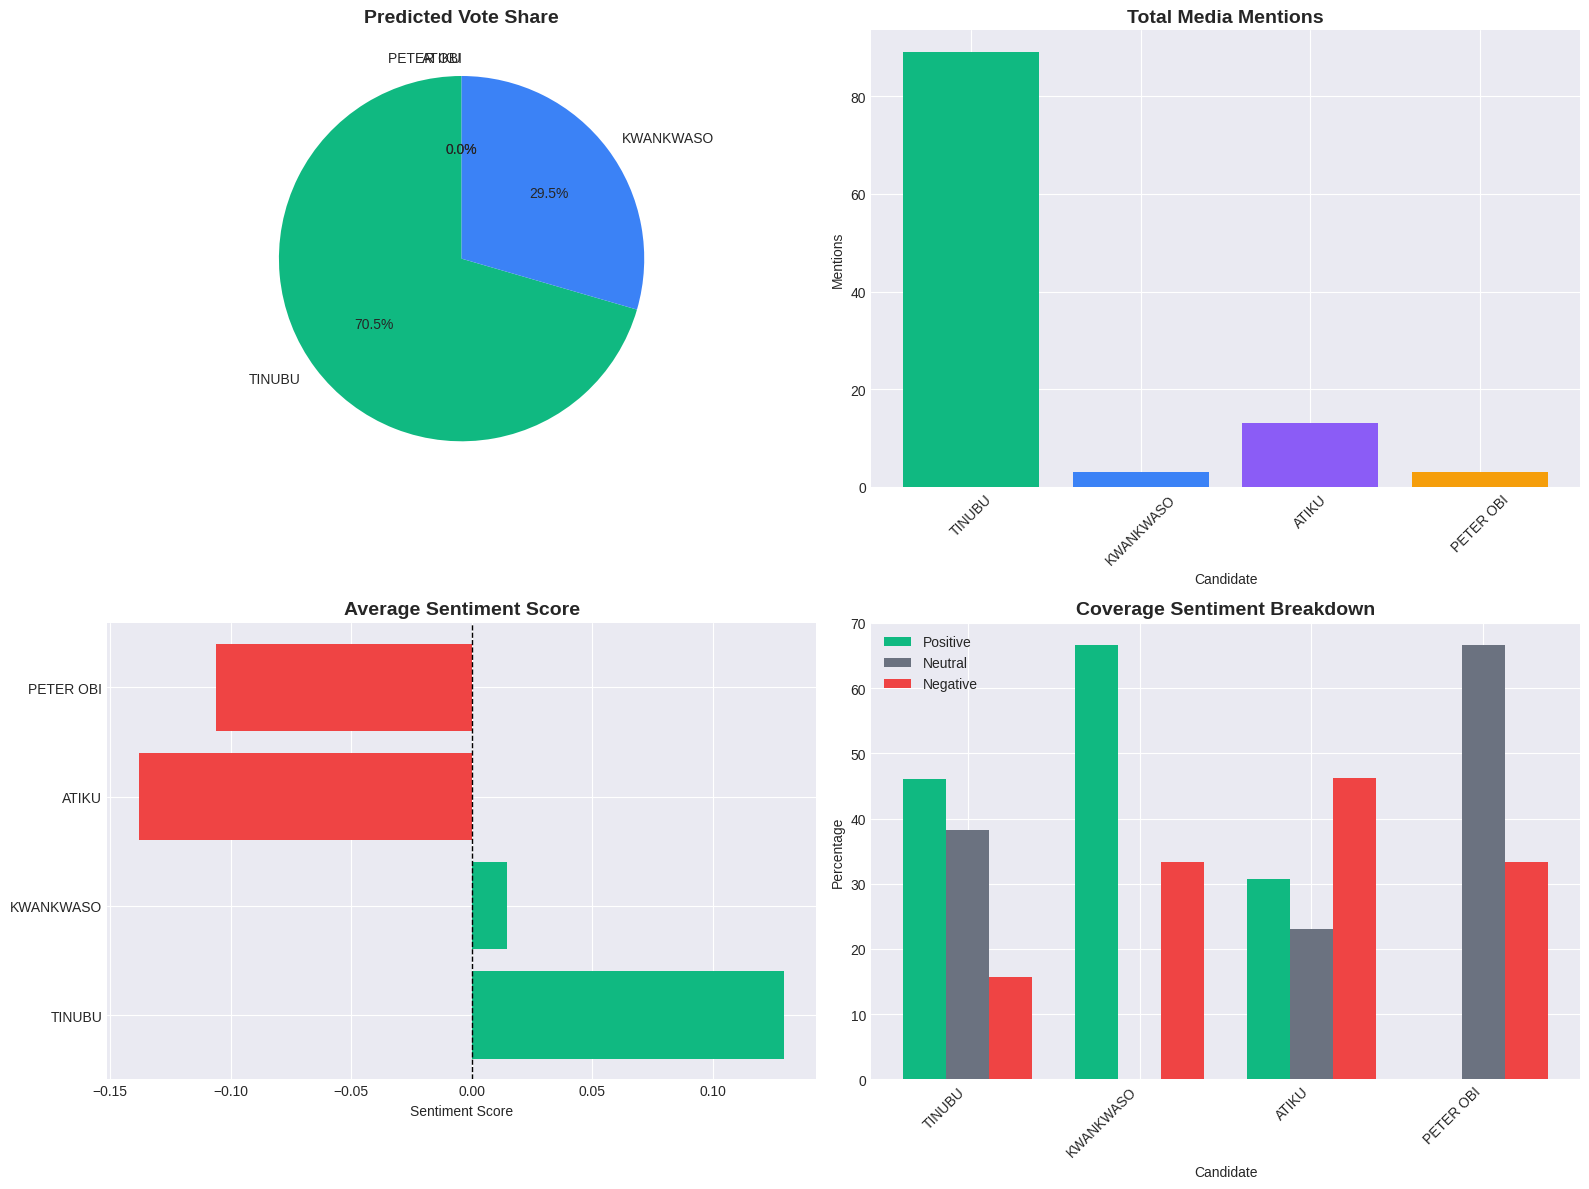

In [15]:
print("\n" + "="*70)
print("ELECTION OUTCOME PREDICTION MODEL")
print("="*70)

# Calculate prediction metrics for each candidate
predictions = []

for candidate in ['TINUBU', 'ATIKU', 'PETER_OBI', 'KWANKWASO']:
    candidate_df = df_clean[df_clean[f'mentions_{candidate}'] == 1]

    total_mentions = len(candidate_df)
    avg_sentiment = candidate_df['compound_score'].mean() if total_mentions > 0 else 0
    positive_count = len(candidate_df[candidate_df['sentiment_label'] == 'Positive'])
    negative_count = len(candidate_df[candidate_df['sentiment_label'] == 'Negative'])
    neutral_count = len(candidate_df[candidate_df['sentiment_label'] == 'Neutral'])

    positive_rate = (positive_count / total_mentions * 100) if total_mentions > 0 else 0
    negative_rate = (negative_count / total_mentions * 100) if total_mentions > 0 else 0

    # Prediction formula
    prediction_score = (
        (total_mentions * 0.4) +
        (avg_sentiment * 50) +
        (positive_rate * 0.5) -
        (negative_rate * 0.3)
    )

    predictions.append({
        'Candidate': candidate.replace('_', ' '),
        'Total Mentions': total_mentions,
        'Avg Sentiment': round(avg_sentiment, 4),
        'Positive Coverage (%)': round(positive_rate, 2),
        'Negative Coverage (%)': round(negative_rate, 2),
        'Neutral Coverage (%)': round((neutral_count / total_mentions * 100) if total_mentions > 0 else 0, 2),
        'Prediction Score': round(prediction_score, 2)
    })

# Create predictions dataframe
predictions_df = pd.DataFrame(predictions)
predictions_df = predictions_df.sort_values('Prediction Score', ascending=False)

# Calculate predicted vote share
# Ensure prediction scores are non-negative for vote share calculation for the pie chart
predictions_df['Non_Negative_Prediction_Score'] = predictions_df['Prediction Score'].apply(lambda x: max(0, x))

total_score = predictions_df['Non_Negative_Prediction_Score'].sum()
if total_score > 0:
    predictions_df['Predicted Vote Share (%)'] = (
        predictions_df['Non_Negative_Prediction_Score'] / total_score * 100
    ).round(2)
else:
    predictions_df['Predicted Vote Share (%)'] = 0

predictions_df['Rank'] = range(1, len(predictions_df) + 1)

# Display predictions
print("\n" + "="*70)
print("FINAL ELECTION PREDICTIONS")
print("="*70)
print(predictions_df.to_string(index=False))

# Visualize predictions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Predicted vote share
colors = ['#10b981', '#3b82f6', '#8b5cf6', '#f59e0b']
axes[0, 0].pie(predictions_df['Predicted Vote Share (%)'],
              labels=predictions_df['Candidate'],
              autopct='%1.1f%%', colors=colors, startangle=90)
axes[0, 0].set_title('Predicted Vote Share', fontsize=14, fontweight='bold')

# Total mentions
axes[0, 1].bar(predictions_df['Candidate'], predictions_df['Total Mentions'],
              color=colors)
axes[0, 1].set_title('Total Media Mentions', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Candidate')
axes[0, 1].set_ylabel('Mentions')
axes[0, 1].tick_params(axis='x', rotation=45)

# Average sentiment
sentiment_colors = ['#10b981' if x > 0 else '#ef4444'
                   for x in predictions_df['Avg Sentiment']]
axes[1, 0].barh(predictions_df['Candidate'], predictions_df['Avg Sentiment'],
               color=sentiment_colors)
axes[1, 0].set_title('Average Sentiment Score', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Sentiment Score')
axes[1, 0].axvline(x=0, color='black', linestyle='--', linewidth=1)

# Coverage breakdown
x = np.arange(len(predictions_df))
width = 0.25
axes[1, 1].bar(x - width, predictions_df['Positive Coverage (%)'], width,
              label='Positive', color='#10b981')
axes[1, 1].bar(x, predictions_df['Neutral Coverage (%)'], width,
              label='Neutral', color='#6b7280')
axes[1, 1].bar(x + width, predictions_df['Negative Coverage (%)'], width,
              label='Negative', color='#ef4444')
axes[1, 1].set_title('Coverage Sentiment Breakdown', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Candidate')
axes[1, 1].set_ylabel('Percentage')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(predictions_df['Candidate'], rotation=45, ha='right')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 9. EXPORT RESULTS

In [16]:
print("\n" + "="*70)
print("EXPORTING RESULTS")
print("="*70)

# Save predictions
predictions_df.to_csv('election_predictions.csv', index=False)
print("✓ Saved: election_predictions.csv")

# Save processed dataset
df_clean.to_csv('processed_dataset.csv', index=False)
print("✓ Saved: processed_dataset.csv")

# Save detailed sentiment analysis
sentiment_summary = df_clean[[
    'article_id', 'text', 'candidate', 'sentiment_label',
    'compound_score', 'positive_score', 'negative_score',
    'neutral_score', 'mentions_TINUBU', 'mentions_ATIKU',
    'mentions_PETER_OBI', 'mentions_KWANKWASO'
]]
sentiment_summary.to_csv('sentiment_analysis_results.csv', index=False)
print("✓ Saved: sentiment_analysis_results.csv")

# Generate text report
with open('election_analysis_report.txt', 'w', encoding='utf-8') as f:
    f.write("="*70 + "\n")
    f.write("NIGERIAN ELECTION SENTIMENT ANALYSIS REPORT\n")
    f.write("="*70 + "\n\n")
    f.write(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Total Articles: {len(df_clean)}\n\n")
    f.write("PREDICTIONS:\n")
    f.write(predictions_df.to_string(index=False))
    f.write("\n\n" + "="*70)

print("✓ Saved: election_analysis_report.txt")

print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print("="*70)
print(f"\nWinner Prediction: {predictions_df.iloc[0]['Candidate']}")
print(f"Predicted Vote Share: {predictions_df.iloc[0]['Predicted Vote Share (%)']}%")
print("\nAll results have been exported successfully!")


EXPORTING RESULTS
✓ Saved: election_predictions.csv
✓ Saved: processed_dataset.csv
✓ Saved: sentiment_analysis_results.csv
✓ Saved: election_analysis_report.txt

ANALYSIS COMPLETE!

Winner Prediction: TINUBU
Predicted Vote Share: 70.5%

All results have been exported successfully!


## MACHINE LEARNING MODELS FOR ELECTION PREDICTION
## Three Different Approaches: Random Forest, XGBoost, Logistic Regression

### 1. SETUP AND IMPORTS

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Install required libraries
print("Installing required libraries...")
!pip install xgboost scikit-learn imbalanced-learn

# Import ML libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                            precision_score, recall_score, f1_score, roc_auc_score)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from imblearn.over_sampling import SMOTE

print("✓ All libraries imported successfully\n")

Installing required libraries...
✓ All libraries imported successfully



### 2. LOAD PREPROCESSED DATA

In [18]:
print("="*70)
print("LOADING PREPROCESSED DATA")
print("="*70)

# Load the preprocessed dataset from previous step
# Make sure you've run the preprocessing code first
df_clean = pd.read_csv('processed_dataset.csv')

print(f"Dataset loaded: {df_clean.shape}")
print(f"Columns: {list(df_clean.columns)}\n")

LOADING PREPROCESSED DATA
Dataset loaded: (250, 26)
Columns: ['article_id', 'text', 'published', 'domain', 'language', 'candidate', 'source', 'date', 'date_only', 'text_processed', 'text_length', 'word_count', 'extracted_candidates', 'mentions_TINUBU', 'mentions_ATIKU', 'mentions_PETER_OBI', 'mentions_KWANKWASO', 'avg_word_length', 'sentence_count', 'article_length_category', 'sentiment_scores', 'compound_score', 'positive_score', 'negative_score', 'neutral_score', 'sentiment_label']



### 3. FEATURE ENGINEERING FOR ML

FEATURE ENGINEERING FOR MACHINE LEARNING
Articles after removing UNKNOWN: 85

Target distribution:
primary_candidate
TINUBU       79
PETER_OBI     3
ATIKU         3
Name: count, dtype: int64


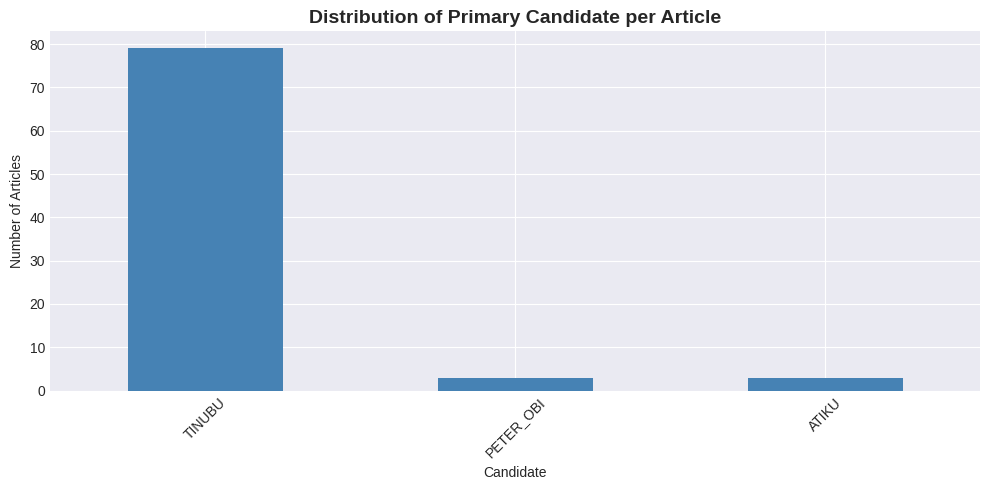


Feature matrix shape: (85, 12)
Target vector shape: (85,)

Features used: ['compound_score', 'positive_score', 'negative_score', 'neutral_score', 'word_count', 'text_length', 'sentence_count', 'avg_word_length', 'mentions_TINUBU', 'mentions_ATIKU', 'mentions_PETER_OBI', 'mentions_KWANKWASO']

Encoded classes: ['ATIKU' 'PETER_OBI' 'TINUBU']


In [19]:
print("="*70)
print("FEATURE ENGINEERING FOR MACHINE LEARNING")
print("="*70)

# Create target variable - the winning candidate for each article
def determine_primary_candidate(row):
    """Determine which candidate is primarily mentioned in article"""
    candidates = {
        'TINUBU': row['mentions_TINUBU'],
        'ATIKU': row['mentions_ATIKU'],
        'PETER_OBI': row['mentions_PETER_OBI'],
        'KWANKWASO': row['mentions_KWANKWASO']
    }

    # Return candidate with most mentions, or 'UNKNOWN' if tied or none
    max_mentions = max(candidates.values())
    if max_mentions == 0:
        return 'UNKNOWN'

    primary = [k for k, v in candidates.items() if v == max_mentions]
    return primary[0] if len(primary) == 1 else 'UNKNOWN'

df_clean['primary_candidate'] = df_clean.apply(determine_primary_candidate, axis=1)

# Remove UNKNOWN candidates for training
df_ml = df_clean[df_clean['primary_candidate'] != 'UNKNOWN'].copy()

print(f"Articles after removing UNKNOWN: {len(df_ml)}")
print(f"\nTarget distribution:")
print(df_ml['primary_candidate'].value_counts())

# Visualize target distribution
plt.figure(figsize=(10, 5))
df_ml['primary_candidate'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Distribution of Primary Candidate per Article', fontsize=14, fontweight='bold')
plt.xlabel('Candidate')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Feature selection
feature_columns = [
    # Sentiment features
    'compound_score',
    'positive_score',
    'negative_score',
    'neutral_score',

    # Text statistics
    'word_count',
    'text_length',
    'sentence_count',
    'avg_word_length',

    # Candidate mentions
    'mentions_TINUBU',
    'mentions_ATIKU',
    'mentions_PETER_OBI',
    'mentions_KWANKWASO'
]

# Create feature matrix and target
X = df_ml[feature_columns].copy()
y = df_ml['primary_candidate'].copy()

# Handle any missing values
X = X.fillna(0)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nFeatures used: {feature_columns}")

# Encode target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"\nEncoded classes: {le.classes_}")


### 4. TRAIN-TEST SPLIT

In [21]:
print("\n" + "="*70)
print("SPLITTING DATA INTO TRAIN AND TEST SETS")
print("="*70)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Feature dimensions: {X_train.shape[1]} features")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled using StandardScaler")

# Handle class imbalance using SMOTE
print("\nHandling class imbalance using SMOTE...")
# Reduced k_neighbors to 1 because minority classes have only 2 samples
smote = SMOTE(random_state=42, k_neighbors=1)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training size: {X_train_scaled.shape[0]}")
print(f"Balanced training size: {X_train_balanced.shape[0]}")
print("\n✓ Class imbalance handled")


SPLITTING DATA INTO TRAIN AND TEST SETS
Training set size: 68 samples
Test set size: 17 samples
Feature dimensions: 12 features
✓ Features scaled using StandardScaler

Handling class imbalance using SMOTE...
Original training size: 68
Balanced training size: 189

✓ Class imbalance handled


### 5. MODEL 1: RANDOM FOREST CLASSIFIER


MODEL 1: RANDOM FOREST CLASSIFIER

Random Forest is an ensemble learning method that:
- Creates multiple decision trees and combines their predictions
- Reduces overfitting through averaging
- Handles non-linear relationships well
- Provides feature importance rankings
- Works well with imbalanced data

Training Random Forest model...
✓ Model trained successfully

--- Random Forest Results ---
Accuracy: 1.0000
Precision (macro): 1.0000
Recall (macro): 1.0000
F1-Score (macro): 1.0000

Classification Report:
              precision    recall  f1-score   support

       ATIKU       1.00      1.00      1.00         1
   PETER_OBI       0.00      0.00      0.00         0
      TINUBU       1.00      1.00      1.00        16

    accuracy                           1.00        17
   macro avg       0.67      0.67      0.67        17
weighted avg       1.00      1.00      1.00        17



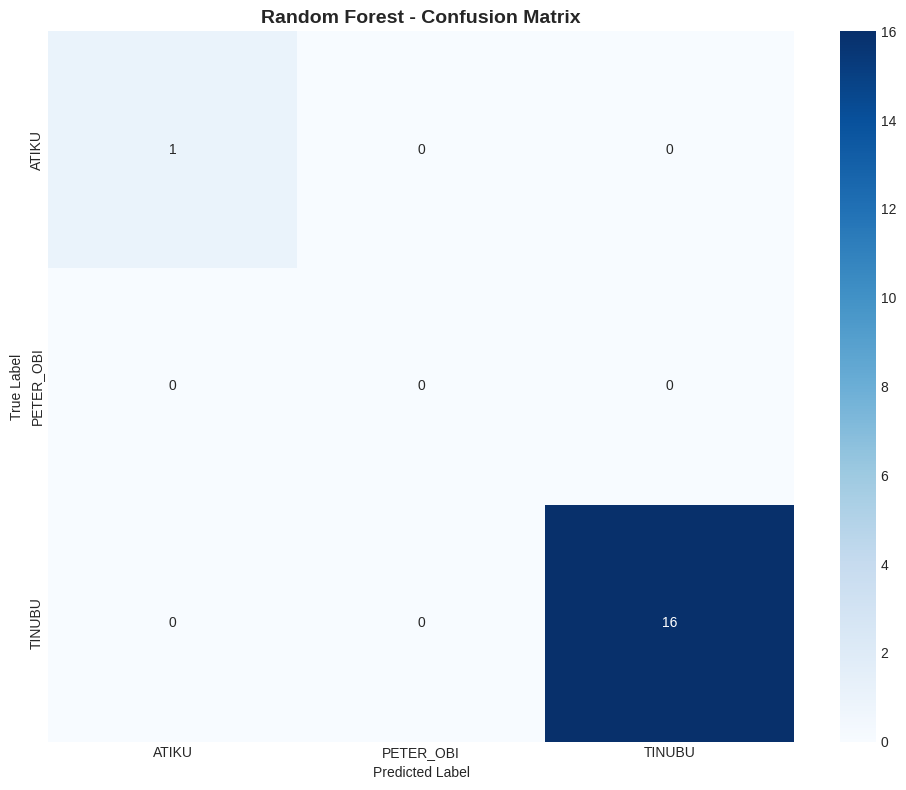

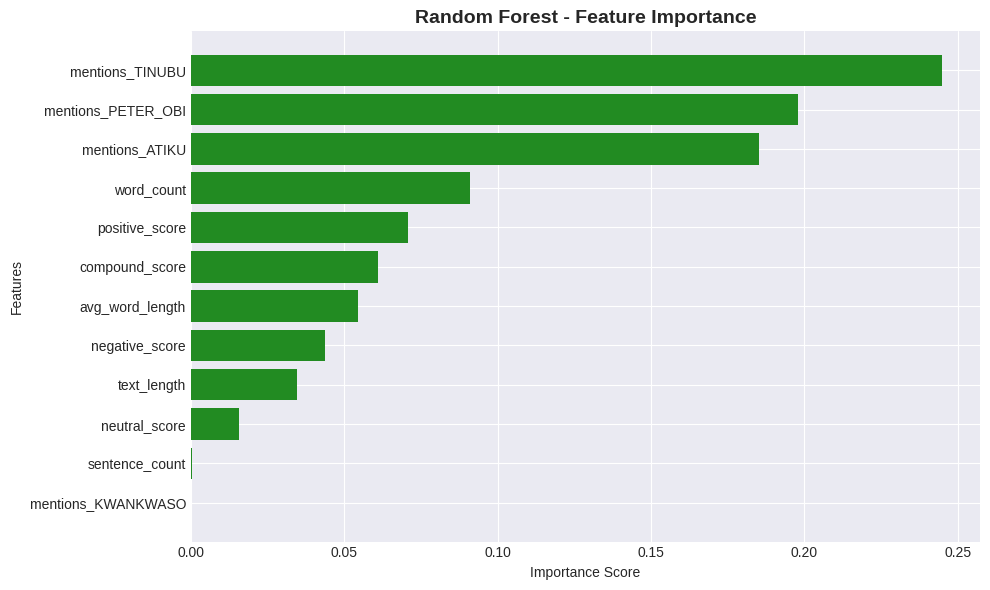


Top 5 Most Important Features:
               Feature  Importance
8      mentions_TINUBU    0.245015
10  mentions_PETER_OBI    0.197823
9       mentions_ATIKU    0.185175
4           word_count    0.090878
1       positive_score    0.070854

Cross-Validation Accuracy: 1.0000 (+/- 0.0000)


In [23]:
print("\n" + "="*70)
print("MODEL 1: RANDOM FOREST CLASSIFIER")
print("="*70)

print("\nRandom Forest is an ensemble learning method that:")
print("- Creates multiple decision trees and combines their predictions")
print("- Reduces overfitting through averaging")
print("- Handles non-linear relationships well")
print("- Provides feature importance rankings")
print("- Works well with imbalanced data\n")

# Train Random Forest
print("Training Random Forest model...")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_balanced, y_train_balanced)
print("✓ Model trained successfully")

# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)

# Evaluation
print("\n--- Random Forest Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision (macro): {precision_score(y_test, y_pred_rf, average='macro', zero_division=0):.4f}")
print(f"Recall (macro): {recall_score(y_test, y_pred_rf, average='macro', zero_division=0):.4f}")
print(f"F1-Score (macro): {f1_score(y_test, y_pred_rf, average='macro', zero_division=0):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, labels=le.transform(le.classes_), target_names=le.classes_, zero_division=0))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=le.transform(le.classes_))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Feature Importance
feature_importance_rf = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_rf['Feature'], feature_importance_rf['Importance'], color='forestgreen')
plt.title('Random Forest - Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(feature_importance_rf.head())

# Cross-validation
cv_scores_rf = cross_val_score(rf_model, X_train_balanced, y_train_balanced, cv=5, scoring='accuracy')
print(f"\nCross-Validation Accuracy: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")

## 6. MODEL 2: XGBOOST CLASSIFIER


MODEL 2: XGBOOST (EXTREME GRADIENT BOOSTING)

XGBoost is a powerful gradient boosting algorithm that:
- Uses gradient boosting framework for high performance
- Handles missing data automatically
- Includes regularization to prevent overfitting
- Often wins Kaggle competitions
- Very fast training with parallel processing

Training XGBoost model...
✓ Model trained successfully

--- XGBoost Results ---
Accuracy: 1.0000
Precision (macro): 1.0000
Recall (macro): 1.0000
F1-Score (macro): 1.0000

Classification Report:
              precision    recall  f1-score   support

       ATIKU       1.00      1.00      1.00         1
   PETER_OBI       0.00      0.00      0.00         0
      TINUBU       1.00      1.00      1.00        16

    accuracy                           1.00        17
   macro avg       0.67      0.67      0.67        17
weighted avg       1.00      1.00      1.00        17



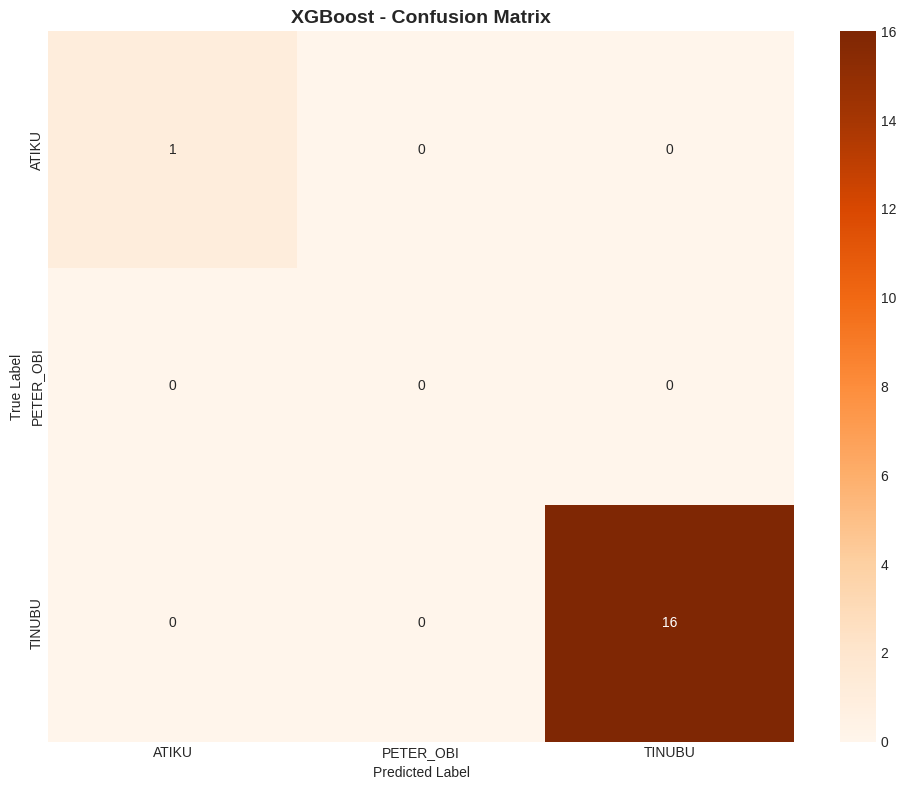

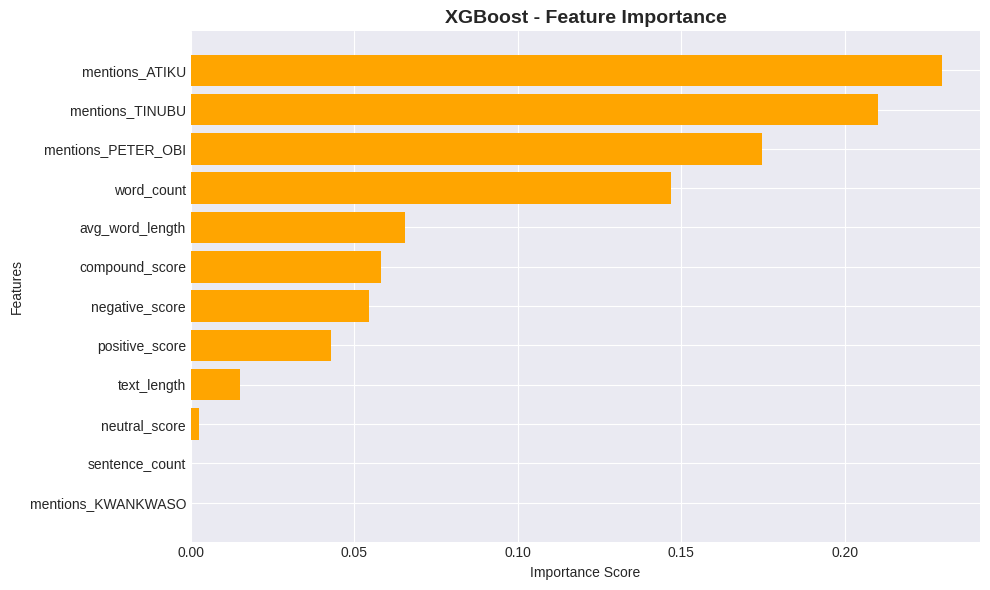


Top 5 Most Important Features:
               Feature  Importance
9       mentions_ATIKU    0.229873
8      mentions_TINUBU    0.210075
10  mentions_PETER_OBI    0.174801
4           word_count    0.146868
7      avg_word_length    0.065385

Cross-Validation Accuracy: 1.0000 (+/- 0.0000)


In [25]:
print("\n" + "="*70)
print("MODEL 2: XGBOOST (EXTREME GRADIENT BOOSTING)")
print("="*70)

print("\nXGBoost is a powerful gradient boosting algorithm that:")
print("- Uses gradient boosting framework for high performance")
print("- Handles missing data automatically")
print("- Includes regularization to prevent overfitting")
print("- Often wins Kaggle competitions")
print("- Very fast training with parallel processing\n")

# Train XGBoost
print("Training XGBoost model...")
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train_balanced, y_train_balanced)
print("✓ Model trained successfully")

# Predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)

# Evaluation
print("\n--- XGBoost Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision (macro): {precision_score(y_test, y_pred_xgb, average='macro', zero_division=0):.4f}")
print(f"Recall (macro): {recall_score(y_test, y_pred_xgb, average='macro', zero_division=0):.4f}")
print(f"F1-Score (macro): {f1_score(y_test, y_pred_xgb, average='macro', zero_division=0):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, labels=le.transform(le.classes_), target_names=le.classes_, zero_division=0))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm_xgb = confusion_matrix(y_test, y_pred_xgb, labels=le.transform(le.classes_))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('XGBoost - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Feature Importance
feature_importance_xgb = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_xgb['Feature'], feature_importance_xgb['Importance'], color='orange')
plt.title('XGBoost - Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(feature_importance_xgb.head())

# Cross-validation
cv_scores_xgb = cross_val_score(xgb_model, X_train_balanced, y_train_balanced, cv=5, scoring='accuracy')
print(f"\nCross-Validation Accuracy: {cv_scores_xgb.mean():.4f} (+/- {cv_scores_xgb.std():.4f})")

## 7. MODEL 3: LOGISTIC REGRESSION


MODEL 3: LOGISTIC REGRESSION

Logistic Regression is a linear model that:
- Simple and highly interpretable
- Fast training and prediction
- Works well when classes are linearly separable
- Provides probability estimates
- Good baseline model for comparison

Training Logistic Regression model...
✓ Model trained successfully

--- Logistic Regression Results ---
Accuracy: 1.0000
Precision (macro): 1.0000
Recall (macro): 1.0000
F1-Score (macro): 1.0000

Classification Report:
              precision    recall  f1-score   support

       ATIKU       1.00      1.00      1.00         1
   PETER_OBI       0.00      0.00      0.00         0
      TINUBU       1.00      1.00      1.00        16

    accuracy                           1.00        17
   macro avg       0.67      0.67      0.67        17
weighted avg       1.00      1.00      1.00        17



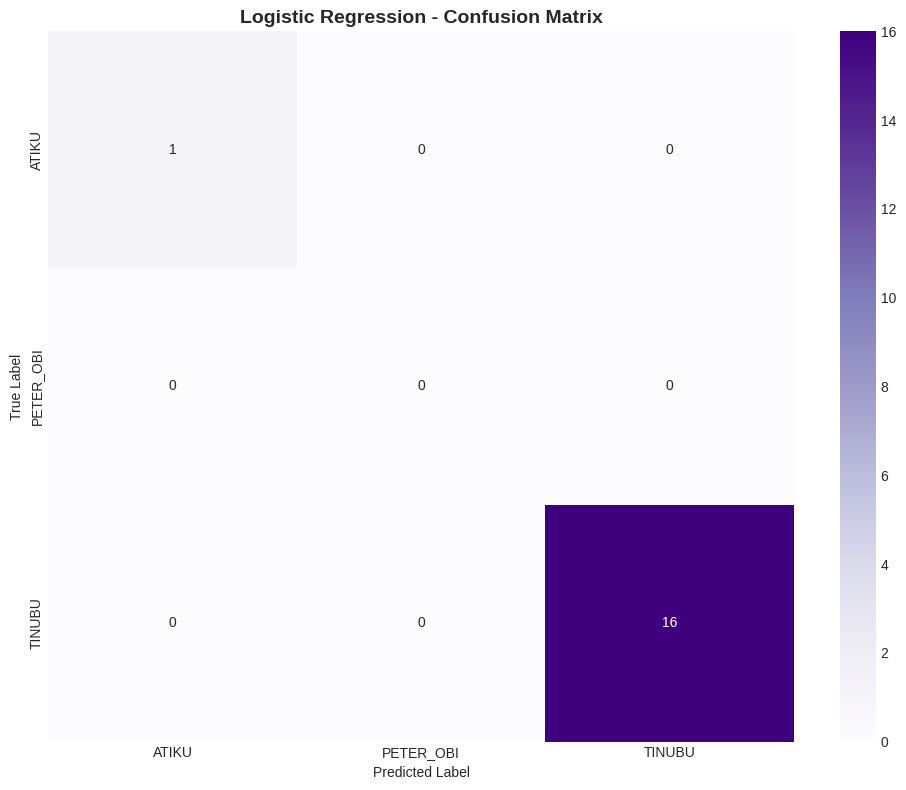

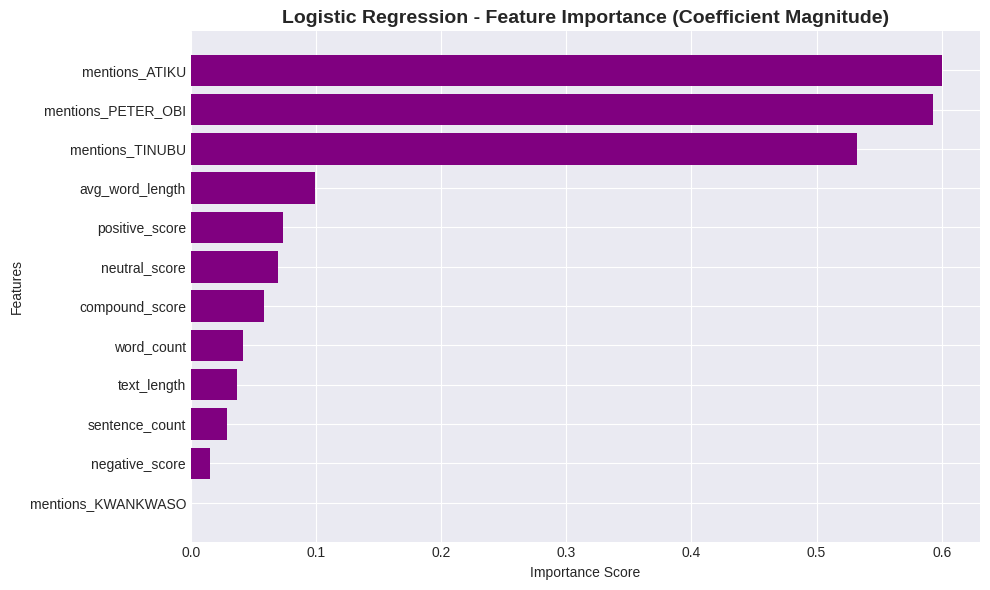


Top 5 Most Important Features:
               Feature  Importance
9       mentions_ATIKU    0.600563
10  mentions_PETER_OBI    0.592894
8      mentions_TINUBU    0.532043
7      avg_word_length    0.099109
1       positive_score    0.073353

Cross-Validation Accuracy: 1.0000 (+/- 0.0000)


In [27]:
print("\n" + "="*70)
print("MODEL 3: LOGISTIC REGRESSION")
print("="*70)

print("\nLogistic Regression is a linear model that:")
print("- Simple and highly interpretable")
print("- Fast training and prediction")
print("- Works well when classes are linearly separable")
print("- Provides probability estimates")
print("- Good baseline model for comparison\n")

# Train Logistic Regression
print("Training Logistic Regression model...")
lr_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=42,
    C=1.0
)

lr_model.fit(X_train_balanced, y_train_balanced)
print("✓ Model trained successfully")

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)

# Evaluation
print("\n--- Logistic Regression Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision (macro): {precision_score(y_test, y_pred_lr, average='macro', zero_division=0):.4f}")
print(f"Recall (macro): {recall_score(y_test, y_pred_lr, average='macro', zero_division=0):.4f}")
print(f"F1-Score (macro): {f1_score(y_test, y_pred_lr, average='macro', zero_division=0):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, labels=le.transform(le.classes_), target_names=le.classes_, zero_division=0))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=le.transform(le.classes_))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Logistic Regression - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Feature Importance (coefficients)
# Average absolute coefficients across all classes
feature_importance_lr = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': np.abs(lr_model.coef_).mean(axis=0)
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_lr['Feature'], feature_importance_lr['Importance'], color='purple')
plt.title('Logistic Regression - Feature Importance (Coefficient Magnitude)',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(feature_importance_lr.head())

# Cross-validation
cv_scores_lr = cross_val_score(lr_model, X_train_balanced, y_train_balanced, cv=5, scoring='accuracy')
print(f"\nCross-Validation Accuracy: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std():.4f})")

# 8. MODEL COMPARISON


COMPREHENSIVE MODEL COMPARISON

Model Performance Comparison:
              Model  Accuracy  Precision  Recall  F1-Score  CV Accuracy
      Random Forest       1.0        1.0     1.0       1.0          1.0
            XGBoost       1.0        1.0     1.0       1.0          1.0
Logistic Regression       1.0        1.0     1.0       1.0          1.0


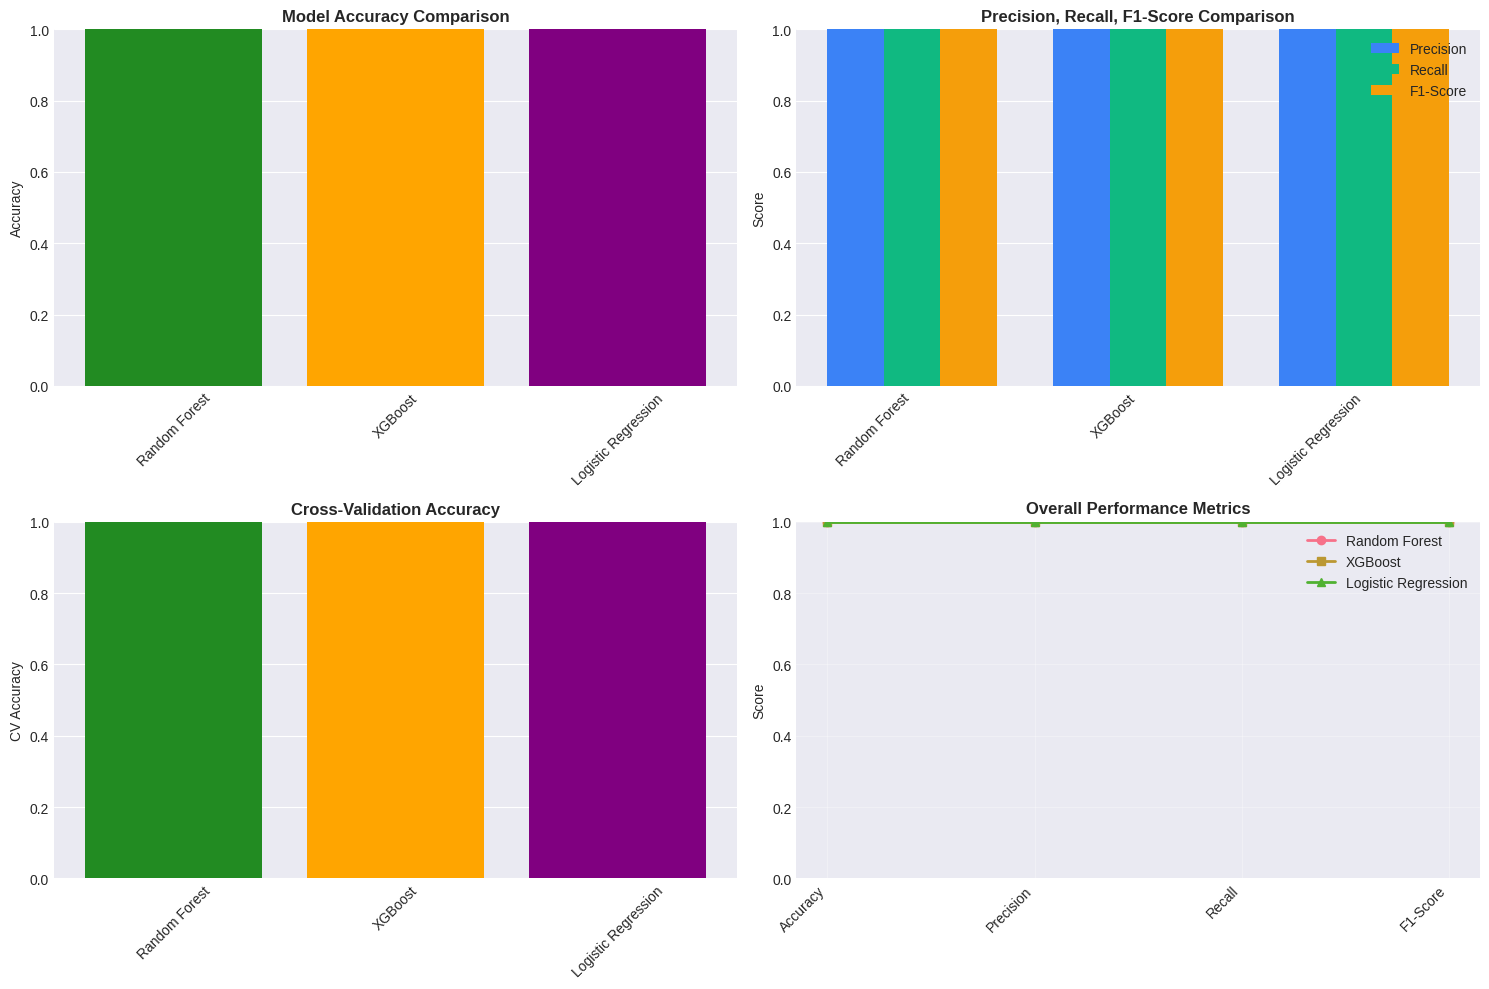


🏆 BEST MODEL: Random Forest
   Accuracy: 1.0000


In [28]:
print("\n" + "="*70)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*70)

# Create comparison dataframe
comparison_results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lr)
    ],
    'Precision': [
        precision_score(y_test, y_pred_rf, average='macro'),
        precision_score(y_test, y_pred_xgb, average='macro'),
        precision_score(y_test, y_pred_lr, average='macro')
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf, average='macro'),
        recall_score(y_test, y_pred_xgb, average='macro'),
        recall_score(y_test, y_pred_lr, average='macro')
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_rf, average='macro'),
        f1_score(y_test, y_pred_xgb, average='macro'),
        f1_score(y_test, y_pred_lr, average='macro')
    ],
    'CV Accuracy': [
        cv_scores_rf.mean(),
        cv_scores_xgb.mean(),
        cv_scores_lr.mean()
    ]
})

print("\nModel Performance Comparison:")
print(comparison_results.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy comparison
axes[0, 0].bar(comparison_results['Model'], comparison_results['Accuracy'],
              color=['forestgreen', 'orange', 'purple'])
axes[0, 0].set_title('Model Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].tick_params(axis='x', rotation=45)

# Precision, Recall, F1 comparison
x = np.arange(len(comparison_results))
width = 0.25
axes[0, 1].bar(x - width, comparison_results['Precision'], width, label='Precision', color='#3b82f6')
axes[0, 1].bar(x, comparison_results['Recall'], width, label='Recall', color='#10b981')
axes[0, 1].bar(x + width, comparison_results['F1-Score'], width, label='F1-Score', color='#f59e0b')
axes[0, 1].set_title('Precision, Recall, F1-Score Comparison', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(comparison_results['Model'], rotation=45, ha='right')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].legend()

# Cross-validation scores
axes[1, 0].bar(comparison_results['Model'], comparison_results['CV Accuracy'],
              color=['forestgreen', 'orange', 'purple'])
axes[1, 0].set_title('Cross-Validation Accuracy', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('CV Accuracy')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].tick_params(axis='x', rotation=45)

# Overall scores radar chart equivalent (bar chart)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
rf_scores = [comparison_results.loc[0, m] for m in metrics]
xgb_scores = [comparison_results.loc[1, m] for m in metrics]
lr_scores = [comparison_results.loc[2, m] for m in metrics]

x = np.arange(len(metrics))
axes[1, 1].plot(x, rf_scores, marker='o', label='Random Forest', linewidth=2)
axes[1, 1].plot(x, xgb_scores, marker='s', label='XGBoost', linewidth=2)
axes[1, 1].plot(x, lr_scores, marker='^', label='Logistic Regression', linewidth=2)
axes[1, 1].set_title('Overall Performance Metrics', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metrics, rotation=45, ha='right')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find best model
best_model_idx = comparison_results['Accuracy'].idxmax()
best_model_name = comparison_results.loc[best_model_idx, 'Model']
best_accuracy = comparison_results.loc[best_model_idx, 'Accuracy']

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Accuracy: {best_accuracy:.4f}")

# 9. ELECTION PREDICTION USING BEST MODEL


ELECTION OUTCOME PREDICTION

--- Random Forest Prediction ---
Predicted Vote Share:
  ATIKU: 3 votes (3.53%)
  PETER_OBI: 3 votes (3.53%)
  TINUBU: 79 votes (92.94%)

--- XGBoost Prediction ---
Predicted Vote Share:
  ATIKU: 3 votes (3.53%)
  PETER_OBI: 3 votes (3.53%)
  TINUBU: 79 votes (92.94%)

--- Logistic Regression Prediction ---
Predicted Vote Share:
  ATIKU: 3 votes (3.53%)
  PETER_OBI: 3 votes (3.53%)
  TINUBU: 79 votes (92.94%)


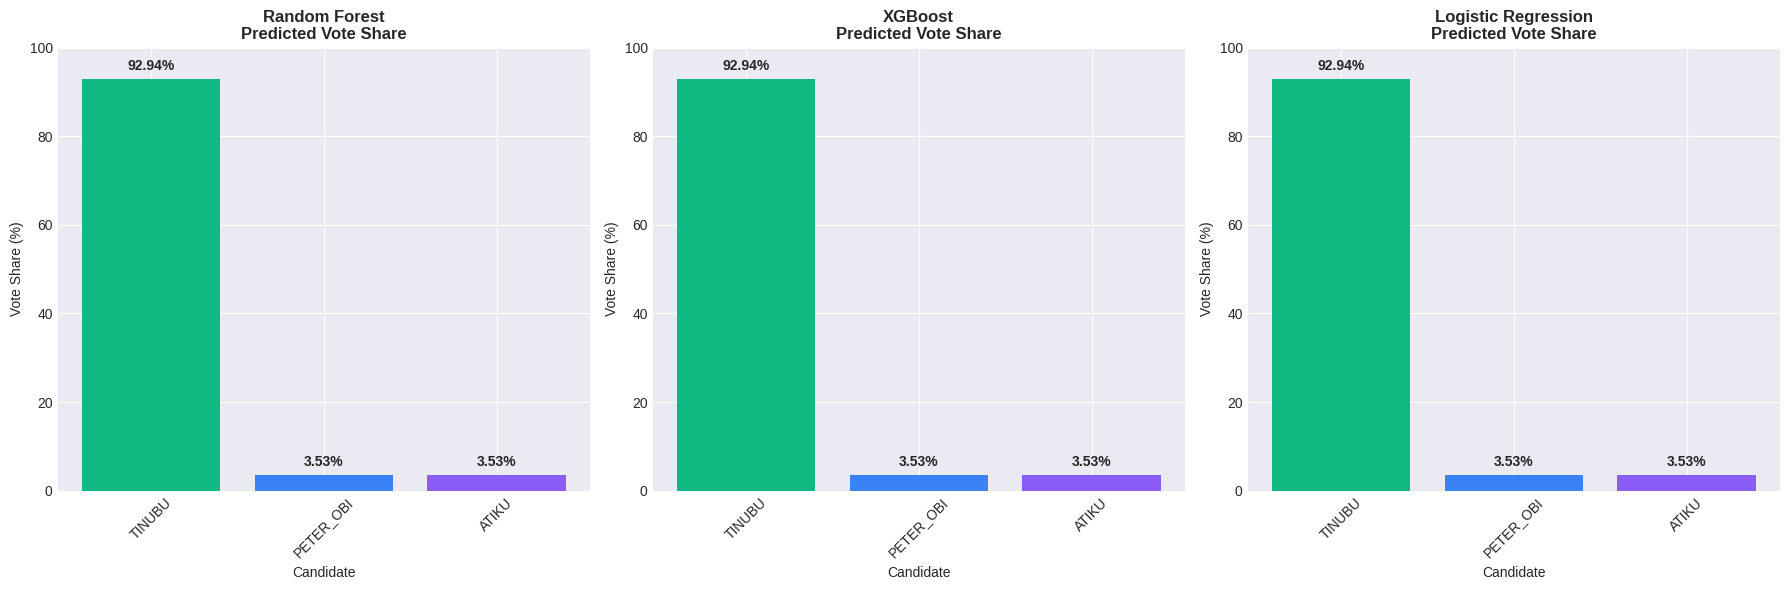


--- ENSEMBLE PREDICTION (Majority Voting) ---
Ensemble Predicted Vote Share:
  ATIKU: 3 votes (3.53%)
  PETER_OBI: 3 votes (3.53%)
  TINUBU: 79 votes (92.94%)


In [29]:
print("\n" + "="*70)
print("ELECTION OUTCOME PREDICTION")
print("="*70)

# Use all three models to predict on entire dataset
models = {
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'Logistic Regression': lr_model
}

# Prepare full dataset
X_full = df_ml[feature_columns].fillna(0)
X_full_scaled = scaler.transform(X_full)

# Get predictions from all models
predictions_all_models = {}

for model_name, model in models.items():
    # Get predictions
    y_pred_full = model.predict(X_full_scaled)
    y_pred_proba_full = model.predict_proba(X_full_scaled)

    # Decode predictions
    predictions_decoded = le.inverse_transform(y_pred_full)

    # Count votes for each candidate
    vote_counts = pd.Series(predictions_decoded).value_counts()
    total_votes = len(predictions_decoded)
    vote_percentages = (vote_counts / total_votes * 100).round(2)

    predictions_all_models[model_name] = {
        'vote_counts': vote_counts,
        'vote_percentages': vote_percentages,
        'predictions': predictions_decoded,
        'probabilities': y_pred_proba_full
    }

    print(f"\n--- {model_name} Prediction ---")
    print("Predicted Vote Share:")
    for candidate in le.classes_:
        votes = vote_counts.get(candidate, 0)
        percentage = vote_percentages.get(candidate, 0)
        print(f"  {candidate}: {votes} votes ({percentage}%)")

# Visualize predictions from all models
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (model_name, results) in enumerate(predictions_all_models.items()):
    axes[idx].bar(results['vote_percentages'].index,
                 results['vote_percentages'].values,
                 color=['#10b981', '#3b82f6', '#8b5cf6', '#f59e0b'])
    axes[idx].set_title(f'{model_name}\nPredicted Vote Share',
                       fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Candidate')
    axes[idx].set_ylabel('Vote Share (%)')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].set_ylim([0, 100])

    # Add percentage labels on bars
    for i, (candidate, percentage) in enumerate(results['vote_percentages'].items()):
        axes[idx].text(i, percentage + 2, f'{percentage}%',
                      ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Ensemble prediction (voting)
print("\n--- ENSEMBLE PREDICTION (Majority Voting) ---")
ensemble_predictions = []
for i in range(len(X_full)):
    votes = [
        le.inverse_transform([rf_model.predict(X_full_scaled[i:i+1])])[0],
        le.inverse_transform([xgb_model.predict(X_full_scaled[i:i+1])])[0],
        le.inverse_transform([lr_model.predict(X_full_scaled[i:i+1])])[0]
    ]
    # Get most common prediction
    ensemble_pred = max(set(votes), key=votes.count)
    ensemble_predictions.append(ensemble_pred)

ensemble_vote_counts = pd.Series(ensemble_predictions).value_counts()
ensemble_vote_percentages = (ensemble_vote_counts / len(ensemble_predictions) * 100).round(2)

print("Ensemble Predicted Vote Share:")
for candidate in le.classes_:
    votes = ensemble_vote_counts.get(candidate, 0)
    percentage = ensemble_vote_percentages.get(candidate, 0)
    print(f"  {candidate}: {votes} votes ({percentage}%)")

### 10. EXPORT RESULTS

In [30]:
print("\n" + "="*70)
print("EXPORTING RESULTS")
print("="*70)

# Save model comparison
comparison_results.to_csv('model_comparison_results.csv', index=False)
print("✓ Saved: model_comparison_results.csv")

# Save predictions from each model
for model_name, results in predictions_all_models.items():
    filename = f'predictions_{model_name.replace(" ", "_").lower()}.csv'
    pred_df = pd.DataFrame({
        'candidate': results['vote_counts'].index,
        'vote_count': results['vote_counts'].values,
        'vote_percentage': results['vote_percentages'].values
    })
    pred_df.to_csv(filename, index=False)
    print(f"✓ Saved: {filename}")

# Save ensemble predictions
ensemble_df = pd.DataFrame({
    'candidate': ensemble_vote_counts.index,
    'vote_count': ensemble_vote_counts.values,
    'vote_percentage': ensemble_vote_percentages.values
})
ensemble_df.to_csv('predictions_ensemble.csv', index=False)
print("✓ Saved: predictions_ensemble.csv")

# Generate comprehensive report
with open('ml_models_report.txt', 'w', encoding='utf-8') as f:
    f.write("="*70 + "\n")
    f.write("MACHINE LEARNING ELECTION PREDICTION REPORT\n")
    f.write("="*70 + "\n\n")
    f.write(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Total Articles: {len(df_ml)}\n")
    f.write(f"Training Samples: {len(X_train)}\n")
    f.write(f"Test Samples: {len(X_test)}\n\n")

    f.write("MODEL COMPARISON:\n")
    f.write(comparison_results.to_string(index=False))
    f.write(f"\n\nBest Model: {best_model_name} (Accuracy: {best_accuracy:.4f})\n\n")

    f.write("="*70 + "\n")
    f.write("ELECTION PREDICTIONS BY MODEL:\n")
    f.write("="*70 + "\n\n")

    for model_name, results in predictions_all_models.items():
        f.write(f"\n{model_name}:\n")
        f.write("-" * 40 + "\n")
        for candidate in le.classes_:
            votes = results['vote_counts'].get(candidate, 0)
            percentage = results['vote_percentages'].get(candidate, 0)
            f.write(f"  {candidate}: {percentage}% ({votes} votes)\n")

    f.write("\n" + "="*70 + "\n")
    f.write("ENSEMBLE PREDICTION:\n")
    f.write("="*70 + "\n")
    for candidate in le.classes_:
        votes = ensemble_vote_counts.get(candidate, 0)
        percentage = ensemble_vote_percentages.get(candidate, 0)
        f.write(f"  {candidate}: {percentage}% ({votes} votes)\n")

    f.write("\n" + "="*70 + "\n")
    f.write("WINNER: " + ensemble_vote_counts.index[0] + "\n")
    f.write("="*70 + "\n")

print("✓ Saved: ml_models_report.txt")

print("\n" + "="*70)
print("MACHINE LEARNING ANALYSIS COMPLETE!")
print("="*70)
print(f"\n🏆 Best Performing Model: {best_model_name}")
print(f"📊 Best Model Accuracy: {best_accuracy:.4f}")
print(f"🎯 Predicted Winner: {ensemble_vote_counts.index[0]}")
print(f"📈 Predicted Vote Share: {ensemble_vote_percentages.values[0]}%")
print("\nAll results exported successfully!")



EXPORTING RESULTS
✓ Saved: model_comparison_results.csv
✓ Saved: predictions_random_forest.csv
✓ Saved: predictions_xgboost.csv
✓ Saved: predictions_logistic_regression.csv
✓ Saved: predictions_ensemble.csv
✓ Saved: ml_models_report.txt

MACHINE LEARNING ANALYSIS COMPLETE!

🏆 Best Performing Model: Random Forest
📊 Best Model Accuracy: 1.0000
🎯 Predicted Winner: TINUBU
📈 Predicted Vote Share: 92.94%

All results exported successfully!
